# CF Metagenome Activity Analysis

In [1]:
### load packages
import math
import glob
import gzip
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyarrow as pa
import seaborn as sns
import shap

from scipy.stats import spearmanr, pearsonr, fisher_exact
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({'font.size': 14})

# Set all possible seeds
np.random.seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### Load input files
uhvdb_final_metadata = pl.read_csv('../figure_s17/uhvdb_v5_final_metadata_v2.tsv', separator='\t')
genome_to_species = uhvdb_final_metadata.select(['uhvdb_id', 'species_cluster_id']).unique()
read_depth = (
    pl.read_csv('cf_metag_read_depth.txt.gz', separator='\t', has_header=False)
        .rename({'column_1': 'sample_id', 'column_2': 'read_depth'})
)
coverm = pl.read_csv('cf_metag_coverm_results.tsv.gz', separator='\t')
sylph_tax = pl.read_csv('cf_metag_sylph_tax_results.tsv.gz', separator='\t')

classify = pl.read_csv('cf_metag_results/2026-04-08_outputs/classify/new_mq_plus_classify_2.tsv.gz', separator='\t')
vclust = pl.read_csv('cf_metag_results/2026-04-08_outputs/assemblyanalyze/vclust_new2all/new_mq_plus_viruses/new_mq_plus_viruses_2.ani.tsv.gz', separator='\t')
propagate = pl.read_csv('cf_metag_propagate.tsv.gz', separator='\t')
mvirs = pl.read_csv('cf_metag_mvirs.tsv.gz', separator='\t')

# Full model

In [3]:
phage_host_ratio_lst = []
sylph_tax_results = []

for sample in sylph_tax['sample_id'].unique():
    sample_id=sample
    df = sylph_tax.filter(pl.col('sample_id') == sample_id)
    virus_df = (
        df
            .filter(pl.col('virus_host').is_not_null())
            .with_columns([
                pl.col('virus_host').str.replace_all(';', '|'),
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.replace(r'.*vSPECIES-', '').str.replace(r'\|.*', '').cast(pl.Int64).alias('species_cluster_id'),
            ])
    )
    sylph_tax_results.append(
        df
            .filter(pl.col('clade_name').str.starts_with('Viruses'))
            .filter(pl.col('clade_name').str.contains('t__'))
            .with_columns([
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.replace(r'.*vSPECIES-', '').str.replace(r'\|.*', '').cast(pl.Int64).alias('species_cluster_id'),
            ])

    )
    bac_df = df.filter(pl.col('clade_name').str.starts_with('d__Bacteria'))
    # join at species level
    species_match = (
        virus_df
            .join(bac_df, left_on='virus_host', right_on='clade_name', how='inner')
            .with_columns([
                (pl.col('taxonomic_abundance') / pl.col('taxonomic_abundance_right')).alias('phage_host_ratio'),
                pl.col('clade_name').str.split('t__').list[1].alias('votu_rep'),
            ])
    )
    phage_host_ratio_lst.append(species_match)
    # join at genus level
    genus_match = (
        virus_df
            .with_columns([pl.col('virus_host').str.split('|s__').list[0]])
            .filter(~pl.col('species_cluster_id').is_in(set(species_match['species_cluster_id'])))
            .join(bac_df, left_on='virus_host', right_on='clade_name', how='inner')
            .with_columns([
                (pl.col('taxonomic_abundance') / pl.col('taxonomic_abundance_right')).alias('phage_host_ratio'),
                pl.col('clade_name').str.split('t__').list[1].alias('votu_rep'),
            ])
    )
    phage_host_ratio_lst.append(genus_match)

phage_host_ratio_df = pl.concat(phage_host_ratio_lst)[['sample_id', 'species_cluster_id', 'phage_host_ratio', 'virus_host']]
sylph_tax_results_df = pl.concat(sylph_tax_results)

In [4]:
# aggregate to species level
cf_metag_data_species = (
    coverm
        .filter(pl.col('breadth_ratio') >= 0.6)
        .join(genome_to_species, left_on='contig_id', right_on='uhvdb_id', how='left')
        .join(uhvdb_final_metadata, on='species_cluster_id', how='left')
        .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
        .filter(pl.col('contig_id') == pl.col('genomovar_rep'))
        .group_by(['species_cluster_id', 'sample_id', 'group'])
        .agg([
            (pl.col('checkv_quality') == 'Complete').sum().alias('complete_count'),
            (pl.col('checkv_quality') == 'High-quality').sum().alias('high_quality_count'),
            (pl.col('n_hallmarks')).median().alias('med_n_hallmarks'),
            ((pl.col('aai_id')/100) * pl.col('aai_af')).median().alias('med_aai_id_af'),
            (pl.col('viral_genes')).median().alias('med_viral_genes'),
            (pl.col('host_genes')).median().alias('med_host_genes'),
            # identify most common ictv class
            pl.col('ictv_class').mode().alias('most_common_ictv_class'),
            pl.col('family_cluster_id').mode().alias('most_common_family_cluster_id'),
            # get the most common family
            pl.col('host_lineage').mode().alias('most_common_host_taxonomy'),
            pl.col('phist_genus_connections').median().alias('med_phist_genus_connections'),
            pl.col('phist_species_connections').median().alias('med_phist_species_connections'),
            pl.col('phist_family_connections').median().alias('med_phist_family_connections'),
            pl.col('crispr_genus_connections').median().alias('med_crispr_genus_connections'),
            pl.col('crispr_species_connections').median().alias('med_crispr_species_connections'),
            pl.col('crispr_family_connections').median().alias('med_crispr_family_connections'),
            (pl.col('virulent').median()).alias('med_virulent_score'),
            ((pl.col('phrog_integration_excision')).median() + (pl.col('empathi_integration')).median()).alias('med_integration_related'),
            (pl.col('num_uniprot_ips').median() / pl.col('num_proteins').median()).alias('mean_proportion_uniprot_ips'),
            (pl.col('num_capsid').median()).alias('med_num_capsid'),
            (pl.col('num_tail').median()).alias('med_num_tail'),
            (pl.col('num_lysis').median()).alias('med_num_lysis'),
            (pl.col('mcp_hallmark').median()).alias('med_mcp_hallmark'),
            (pl.col('terl_hallmark').median()).alias('med_terL_hallmark'),
            (pl.col('portal_hallmark').median()).alias('med_portal_hallmark'),
            (pl.col('breadth').median()).alias('breadth'),
            (pl.col('breadth_ratio').median()).alias('breadth_ratio'),
            (pl.col('variance').median()).alias('variance'),
            (pl.col('trimmed_mean').median()).alias('trimmed_mean'),
            (pl.col('length').median()).alias('genome_length'),
        ])
        .with_columns([
            (pl.col('variance')/pl.col('trimmed_mean')).alias('variance_ratio'),
        ])
        .join(phage_host_ratio_df, left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
        .join(sylph_tax_results_df.select(['species_cluster_id', 'sample_id', 'ani']), left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
        .unique(['species_cluster_id', 'sample_id'])
        .fill_null(0.00)
)
cf_metag_data_species.height

55092

In [5]:
import joblib
import polars as pl
import pandas as pd
import numpy as np

# =============================================================================
# 1. LOAD MODEL AND METADATA
# =============================================================================
pipeline = joblib.load("../figure_s14/phage_activity_model_full.joblib")
metadata = joblib.load("../figure_s14/phage_model_metadata_full.joblib")

# Extract info from metadata
required_features = metadata["numeric_cols"]
t90 = metadata["thresh_90"]
t75 = metadata["thresh_75"]
t50 = metadata["thresh_50"]

# =============================================================================
# 2. LOAD AND PREPROCESS NEW DATA
# =============================================================================
# Assuming df_new is your unseen dataset (metagenomic contigs/sequences)
# We use Polars for the heavy lifting
processed_results = cf_metag_data_species

# =============================================================================
# 3. GENERATE PREDICTIONS
# =============================================================================
# Scikit-learn expects the exact columns in the exact order as training
X_new = processed_results.select(required_features).to_pandas()
X_new = X_new.replace([np.inf, -np.inf], np.nan)

# Get probability of "Active" (Class 1)
probs = pipeline.predict_proba(X_new)[:, 1]

# =============================================================================
# 4. CATEGORIZE BY CONFIDENCE TIERS
# =============================================================================
final_df = processed_results.with_columns([
    pl.Series("activity_probability", probs)
]).with_columns([
    pl.when(pl.col("activity_probability") >= t90).then(pl.lit("High"))
    .when(pl.col("activity_probability") >= t75).then(pl.lit("Medium"))
    .when(pl.col("activity_probability") >= t50).then(pl.lit("Low"))
    .otherwise(pl.lit("No Prediction"))
    .alias("confidence_tier")
])

# =============================================================================
# 5. OUTPUT
# =============================================================================
print("Classification Summary:")
print(final_df["confidence_tier"].value_counts())

# Save your hits
# final_df.write_csv("new_phage_predictions.csv")

Classification Summary:
shape: (4, 2)
┌─────────────────┬───────┐
│ confidence_tier ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ Low             ┆ 18105 │
│ Medium          ┆ 5999  │
│ High            ┆ 158   │
│ No Prediction   ┆ 30830 │
└─────────────────┴───────┘


In [6]:
all_viruses = (
    final_df
        .join(read_depth, on='sample_id', how='left')
        .with_columns((pl.col('read_depth') / 1e9).alias('read_depth_gbp'))
        .group_by(['sample_id', 'read_depth'])
        .len()
        .with_columns([pl.lit('No filter').alias('confidence_tier')])
)

lc_viruses = (
    final_df
        .join(read_depth, on='sample_id', how='left')
        .with_columns((pl.col('read_depth') / 1e9).alias('read_depth_gbp'))
        .filter(pl.col('confidence_tier') != 'No Prediction')
        .group_by(['sample_id', 'read_depth'])
        .len()
        .with_columns([pl.lit('Low-confidence').alias('confidence_tier')])
)

mc_viruses = (
    final_df
        .join(read_depth, on='sample_id', how='left')
        .with_columns((pl.col('read_depth') / 1e9).alias('read_depth_gbp'))
        .filter(pl.col('confidence_tier').is_in(['Medium', 'High']))
        .group_by(['sample_id', 'read_depth'])
        .len()
        .with_columns([pl.lit('Medium-confidence').alias('confidence_tier')])
)

hc_viruses = (
    final_df
        .join(read_depth, on='sample_id', how='left')
        .with_columns((pl.col('read_depth') / 1e9).alias('read_depth_gbp'))
        .filter(pl.col('confidence_tier').is_in(['High']))
        .group_by(['sample_id', 'read_depth'])
        .len()
        .with_columns([pl.lit('High-confidence').alias('confidence_tier')])
)

combined = (
    pl.concat([all_viruses, lc_viruses, mc_viruses, hc_viruses])
)

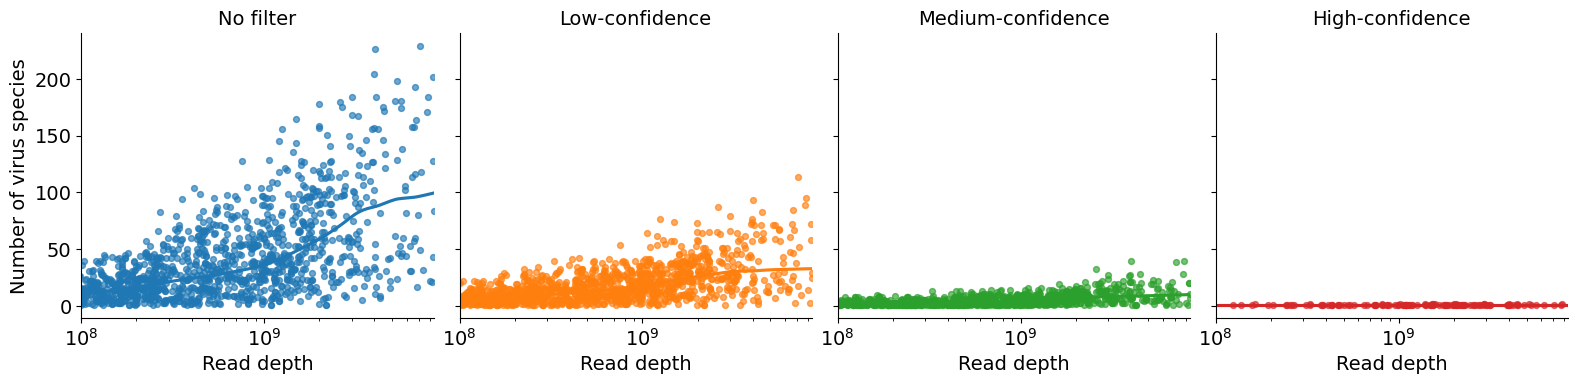

In [7]:
# Faceted LOWESS plot: number of virus species vs read depth (Polars-native table)
plot_df = combined

# Keep explicit facet order
tier_order = ['No filter', 'Low-confidence', 'Medium-confidence', 'High-confidence']

# Compute x-axis cap from Polars (99th percentile)
x_max = plot_df.select(pl.col('read_depth').quantile(0.99)).item()

g = sns.FacetGrid(
    plot_df,
    col='confidence_tier',
    col_order=tier_order,
    col_wrap=4,
    height=4.0,
    sharex=True,
    sharey=True,
    margin_titles=True,
    hue='confidence_tier'
 )

g.map_dataframe(
    sns.regplot,
    x='read_depth',
    y='len',
    lowess=True,
    scatter_kws={'s': 18, 'alpha': 0.65},
 )

for ax in g.axes.flatten():
    ax.set_xlim(1e8, x_max)

g.set_axis_labels('Read depth', 'Number of virus species')
g.set_titles(col_template='{col_name}')
g.fig.subplots_adjust(top=0.90)
plt.xscale("log")
plt.show()

# Assembly model

In [8]:
checkv_df = (
    classify
        .with_columns([
            pl.when(pl.col('contig_length').is_not_null()).then(pl.col('contig_length')).otherwise(pl.col('proviral_length')).alias('contig_length')
        ])
        .group_by('seq_name')
        .agg([
            ((pl.col('topology').str.contains('TR')) | (pl.col('completeness_method').str.contains('TR'))).sum().alias('circular_count'),
            (pl.col('completeness').max()).alias('max_completeness'),
            (pl.col('n_hallmarks').max()).alias('max_n_hallmarks'),
            (pl.col('viral_genes').max()).alias('max_viral_genes'),
            (pl.col('host_genes').max()).alias('max_host_genes'),
            (pl.col('contig_length').max()).alias('max_contig_length'),
        ])
)

In [9]:
### load unenriched vs uhvdb blast results
vclust_sample_lst = []
for sample in list(set(coverm['sample_id'])):
    df = vclust.filter(pl.col('query').str.contains(sample))
    uhvdb_hits_in_sample = set(coverm.filter((pl.col('sample_id') == sample) & (pl.col('breadth_ratio') >= 0.6))['contig_id'])
    vclust_sample_lst.append(
        df.filter(pl.col('reference').is_in(uhvdb_hits_in_sample))
            .sort('gani', descending=True)
            .unique('query', maintain_order=True)
            .unique(['reference'], maintain_order=True)
            .with_columns([pl.lit(sample).alias('sample_id')])
            .filter(pl.col('gani') >= 0.0)
    )
unenriched_v_uhvdb_vclust = pl.concat(vclust_sample_lst).join(genome_to_species, left_on='reference', right_on='uhvdb_id', how='left')

In [10]:
# aggregate to species level
cf_metag_assem_data_species = (
    coverm
        .join(genome_to_species, left_on='contig_id', right_on='uhvdb_id', how='left')
        .join(uhvdb_final_metadata, on='species_cluster_id', how='left')
        .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
        .filter(pl.col('contig_id') == pl.col('genomovar_rep'))
        .join(unenriched_v_uhvdb_vclust[['query', 'gani', 'ani', 'sample_id', 'species_cluster_id']], on=['species_cluster_id', 'sample_id'], how='left')
        .join(checkv_df, left_on='query', right_on='seq_name', how='left')
        .join(propagate, left_on=['query', 'sample_id'], right_on=['prophage', 'sample_id'], how='left')
        .with_columns([
            pl.col('query').str.split('|provirus').list[0].alias('contig_id_no_prophage')
        ])
        .join(mvirs[['contig_id_no_prophage', 'num_oprs', 'num_clipped', 'sample_id']], on=['contig_id_no_prophage', 'sample_id'], how='left')
        .filter(pl.col('query').is_not_null())
        .group_by(['species_cluster_id', 'sample_id', 'group'])
        .agg([
            (pl.col('checkv_quality') == 'Complete').sum().alias('complete_count'),
            (pl.col('checkv_quality') == 'High-quality').sum().alias('high_quality_count'),
            (pl.col('n_hallmarks')).median().alias('med_n_hallmarks'),
            ((pl.col('aai_id')/100) * pl.col('aai_af')).median().alias('med_aai_id_af'),
            (pl.col('viral_genes')).median().alias('med_viral_genes'),
            (pl.col('host_genes')).median().alias('med_host_genes'),
            (pl.col('ani')).median().alias('assem_med_ani'),
            (pl.col('circular_count')).median().alias('assem_complete_count'),
            (pl.col('max_n_hallmarks')).median().alias('assem_med_n_hallmarks'),
            (pl.col('max_contig_length')).median().alias('assem_med_contig_length'),
            (pl.col('max_viral_genes')).median().alias('assem_med_viral_genes'),
            (pl.col('max_host_genes')).median().alias('assem_med_host_genes'),
            (pl.col('CohenD')).median().alias('assem_med_cohend'),
            (pl.col('prophage-host_ratio')).median().alias('assem_med_prophage_host'),
            (pl.col('num_oprs').median()).alias('assem_med_num_oprs'),
            (pl.col('num_clipped').median()).alias('assem_med_num_clipped'),
            (pl.col('virulent').median()).alias('med_virulent_score'),
            ((pl.col('phrog_integration_excision')).median() + (pl.col('empathi_integration')).median()).alias('med_integration_related'),
            (pl.col('num_capsid').median()).alias('med_num_capsid'),
            (pl.col('num_tail').median()).alias('med_num_tail'),
            (pl.col('num_lysis').median()).alias('med_num_lysis'),
            (pl.col('mcp_hallmark').median()).alias('med_mcp_hallmark'),
            (pl.col('terl_hallmark').median()).alias('med_terL_hallmark'),
            (pl.col('portal_hallmark').median()).alias('med_portal_hallmark'),
            (pl.col('breadth').median()).alias('breadth'),
            (pl.col('breadth_ratio').median()).alias('breadth_ratio'),
            (pl.col('variance').median()).alias('variance'),
            (pl.col('trimmed_mean').median()).alias('trimmed_mean'),
            (pl.col('length').median()).alias('genome_length'),
        ])
        .with_columns([
            (pl.col('variance')/pl.col('trimmed_mean')).alias('variance_ratio'),
        ])
        .join(phage_host_ratio_df, left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
        .join(sylph_tax_results_df.select(['species_cluster_id', 'sample_id', 'ani']), left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
        .unique(['species_cluster_id', 'sample_id'])
        .fill_null(0.00)
)
cf_metag_assem_data_species.height

7484

In [11]:
import joblib
import polars as pl
import pandas as pd
import numpy as np

# =============================================================================
# 1. LOAD MODEL AND METADATA
# =============================================================================
assem_pipeline = joblib.load("../figure_s15/phage_activity_model_assembly.joblib")
assem_metadata = joblib.load("../figure_s15/phage_model_metadata_assembly.joblib")

# Extract info from metadata
assem_required_features = assem_metadata["numeric_cols"]
assem_t90 = assem_metadata["thresh_90"]
assem_t75 = assem_metadata["thresh_75"]
assem_t50 = assem_metadata["thresh_50"]

# =============================================================================
# 2. LOAD AND PREPROCESS NEW DATA
# =============================================================================
# Assuming df_new is your unseen dataset (metagenomic contigs/sequences)
# We use Polars for the heavy lifting
assem_processed_results = cf_metag_assem_data_species

# =============================================================================
# 3. GENERATE PREDICTIONS
# =============================================================================
# Scikit-learn expects the exact columns in the exact order as training
assem_X_new = assem_processed_results.select(assem_required_features).to_pandas()
assem_X_new = assem_X_new.replace([np.inf, -np.inf], np.nan)

# Get probability of "Active" (Class 1)
assem_probs = assem_pipeline.predict_proba(assem_X_new)[:, 1]

# =============================================================================
# 4. CATEGORIZE BY CONFIDENCE TIERS
# =============================================================================
assem_final_df = assem_processed_results.with_columns([
    pl.Series("activity_probability", assem_probs)
]).with_columns([
    pl.when(pl.col("activity_probability") >= assem_t90).then(pl.lit("High"))
    .when(pl.col("activity_probability") >= assem_t75).then(pl.lit("Medium"))
    .when(pl.col("activity_probability") >= assem_t50).then(pl.lit("Low"))
    .otherwise(pl.lit("No Prediction"))
    .alias("confidence_tier")
])

# =============================================================================
# 5. OUTPUT
# =============================================================================
print("Classification Summary:")
print(assem_final_df["confidence_tier"].value_counts())

# Save your hits
# assem_final_df.write_csv("new_phage_predictions.csv")

Classification Summary:
shape: (3, 2)
┌─────────────────┬───────┐
│ confidence_tier ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ Medium          ┆ 2144  │
│ High            ┆ 1607  │
│ Low             ┆ 3733  │
└─────────────────┴───────┘


In [12]:
assem_all_viruses = (
    assem_final_df
        .join(read_depth, on='sample_id', how='left')
        .with_columns((pl.col('read_depth') / 1e9).alias('read_depth_gbp'))
        .group_by(['sample_id', 'read_depth'])
        .len()
        .with_columns([pl.lit('No filter').alias('confidence_tier')])
)

assem_lc_viruses = (
    assem_final_df
        .join(read_depth, on='sample_id', how='left')
        .with_columns((pl.col('read_depth') / 1e9).alias('read_depth_gbp'))
        .filter(pl.col('confidence_tier') != 'No Prediction')
        .group_by(['sample_id', 'read_depth'])
        .len()
        .with_columns([pl.lit('Low-confidence').alias('confidence_tier')])
)

assem_mc_viruses = (
    assem_final_df
        .join(read_depth, on='sample_id', how='left')
        .with_columns((pl.col('read_depth') / 1e9).alias('read_depth_gbp'))
        .filter(pl.col('confidence_tier').is_in(['Medium', 'High']))
        .group_by(['sample_id', 'read_depth'])
        .len()
        .with_columns([pl.lit('Medium-confidence').alias('confidence_tier')])
)

assem_hc_viruses = (
    assem_final_df
        .join(read_depth, on='sample_id', how='left')
        .with_columns((pl.col('read_depth') / 1e9).alias('read_depth_gbp'))
        .filter(pl.col('confidence_tier').is_in(['High']))
        .group_by(['sample_id', 'read_depth'])
        .len()
        .with_columns([pl.lit('High-confidence').alias('confidence_tier')])
)

assem_combined = (
    pl.concat([assem_all_viruses, assem_lc_viruses, assem_mc_viruses, assem_hc_viruses])
)

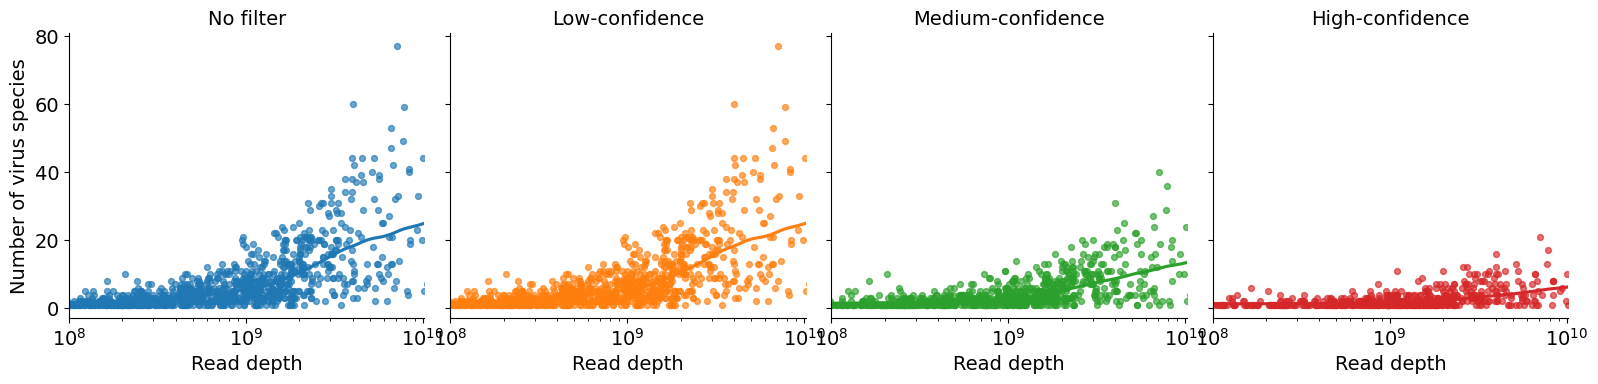

In [13]:
# Faceted LOWESS plot: number of virus species vs read depth (Polars-native table)
assem_plot_df = assem_combined

# Compute x-axis cap from Polars (99th percentile)
assem_x_max = assem_plot_df.select(pl.col('read_depth').quantile(0.99)).item()

g = sns.FacetGrid(
    assem_plot_df,
    col='confidence_tier',
    col_order=tier_order,
    col_wrap=4,
    height=4.0,
    sharex=True,
    sharey=True,
    margin_titles=True,
    hue='confidence_tier'
 )

g.map_dataframe(
    sns.regplot,
    x='read_depth',
    y='len',
    lowess=True,
    scatter_kws={'s': 18, 'alpha': 0.65},
 )

for ax in g.axes.flatten():
    ax.set_xlim(1e8, assem_x_max)

g.set_axis_labels('Read depth', 'Number of virus species')
g.set_titles(col_template='{col_name}')
g.fig.subplots_adjust(top=0.90)
plt.xscale('log')
plt.show()

# Hybrid model (assembly for samples with assemblies, else full)

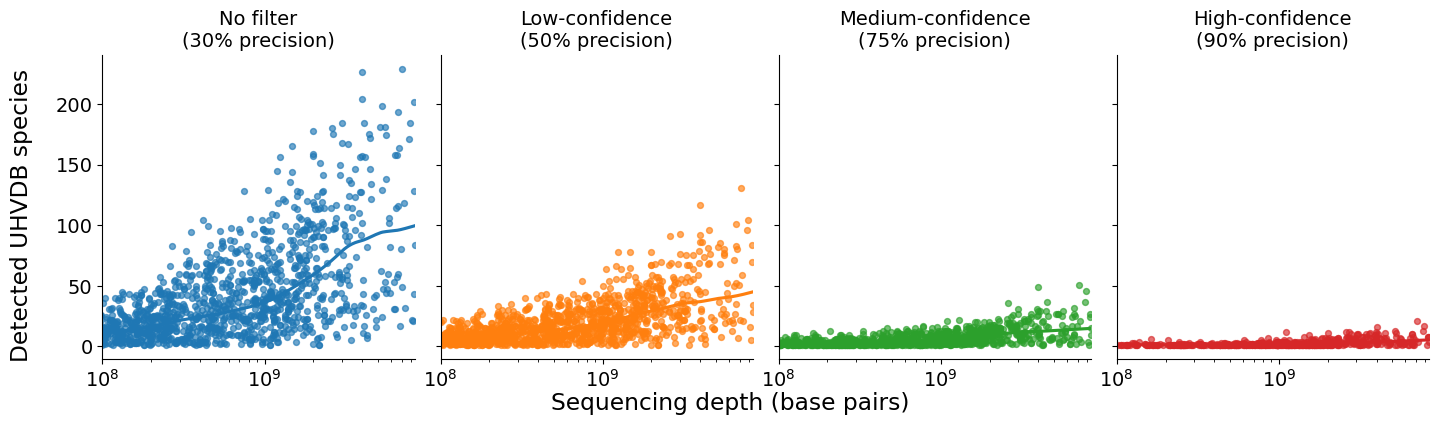

In [14]:
# Hybrid regplots: prefer assembly-model tier per species/sample; fallback to full-model tier
hybrid_key_cols = ['sample_id', 'species_cluster_id']

hybrid_assem_calls = assem_final_df.select(hybrid_key_cols + ['confidence_tier'])
hybrid_full_calls = final_df.select(hybrid_key_cols + ['confidence_tier'])

# Keep full-model calls only where no assembly-model call exists for that species in that sample
hybrid_full_fallback = hybrid_full_calls.join(
    hybrid_assem_calls.select(hybrid_key_cols).unique(),
    on=hybrid_key_cols,
    how='anti'
 )

hybrid_calls = (
    pl.concat([hybrid_assem_calls, hybrid_full_fallback])
      .unique(hybrid_key_cols, maintain_order=True)
 )

hybrid_counts = (
    hybrid_calls
      .join(read_depth, on='sample_id', how='left')
 )

hybrid_all_viruses = (
    hybrid_counts
      .group_by(['sample_id', 'read_depth'])
      .len()
      .with_columns([pl.lit('No filter\n(30% precision)').alias('confidence_tier')])
 )

hybrid_lc_viruses = (
    hybrid_counts
      .filter(pl.col('confidence_tier') != 'No Prediction')
      .group_by(['sample_id', 'read_depth'])
      .len()
      .with_columns([pl.lit('Low-confidence\n(50% precision)').alias('confidence_tier')])
 )

hybrid_mc_viruses = (
    hybrid_counts
      .filter(pl.col('confidence_tier').is_in(['Medium', 'High']))
      .group_by(['sample_id', 'read_depth'])
      .len()
      .with_columns([pl.lit('Medium-confidence\n(75% precision)').alias('confidence_tier')])
 )

hybrid_hc_viruses = (
    hybrid_counts
      .filter(pl.col('confidence_tier') == 'High')
      .group_by(['sample_id', 'read_depth'])
      .len()
      .with_columns([pl.lit('High-confidence\n(90% precision)').alias('confidence_tier')])
 )

hybrid_combined = pl.concat([
    hybrid_all_viruses,
    hybrid_lc_viruses,
    hybrid_mc_viruses,
    hybrid_hc_viruses,
])

# Faceted LOWESS plot (same style as existing plots)
hybrid_plot_df = hybrid_combined

# Keep explicit facet order
hybrid_tier_order = ['No filter\n(30% precision)', 'Low-confidence\n(50% precision)', 'Medium-confidence\n(75% precision)', 'High-confidence\n(90% precision)']

# Compute x-axis cap from Polars (99th percentile)
hybrid_x_max = hybrid_plot_df.select(pl.col('read_depth').quantile(0.99)).item()

g = sns.FacetGrid(
    hybrid_plot_df,
    col='confidence_tier',
    col_order=hybrid_tier_order,
    col_wrap=4,
    height=4.0,
    aspect=0.9,
    sharex=True,
    sharey=True,
    margin_titles=True,
    hue='confidence_tier',
 )

g.map_dataframe(
    sns.regplot,
    x='read_depth',
    y='len',
    lowess=True,
    scatter_kws={'s': 18, 'alpha': 0.65},
 )

for ax in g.axes.flatten():
    ax.set_xlim(1e8, hybrid_x_max)
    ax.set_xscale('log')
    ax.set_xlabel('')

g.set_ylabels('')
g.set_titles(col_template='{col_name}')
g.fig.subplots_adjust(top=0.90, bottom=0.14)
g.fig.supxlabel('Sequencing depth (base pairs)',y=0, x=0.5)
g.fig.supylabel('Detected UHVDB species', x=0)
plt.show()

In [15]:
# LOWESS values by confidence tier at fixed read-depth intervals (1e9 to 10e9)
from statsmodels.nonparametric.smoothers_lowess import lowess

lowess_rows = []
target_x = np.arange(1e9, 10e9 + 1, 1e9, dtype=float)
value_cols = [f"lowess_at_{int(x/1e9)}e9" for x in target_x]

for tier in hybrid_tier_order:
    sub = (
        hybrid_plot_df
        .filter(pl.col('confidence_tier') == tier)
        .select(['read_depth', 'len'])
        .to_pandas()
        .dropna()
        .sort_values('read_depth')
    )

    row = {
        'confidence_tier': tier,
        'n_points': len(sub),
        **{c: np.nan for c in value_cols},
    }

    if len(sub) < 3 or sub['read_depth'].nunique() < 3:
        lowess_rows.append(row)
        continue

    fit = lowess(
        endog=sub['len'],
        exog=sub['read_depth'],
        # frac=0.35,
        return_sorted=True
    )

    x_fit = fit[:, 0]
    y_fit = fit[:, 1]

    for x in target_x:
        # Only interpolate inside fitted LOWESS domain
        if x_fit.min() <= x <= x_fit.max():
            y_val = float(np.interp(x, x_fit, y_fit))
        else:
            y_val = np.nan
        row[f'lowess_at_{int(x/1e9)}e9'] = y_val

    lowess_rows.append(row)

hybrid_lowess_interval_table = pl.DataFrame(lowess_rows)
hybrid_lowess_interval_table

confidence_tier,n_points,lowess_at_1e9,lowess_at_2e9,lowess_at_3e9,lowess_at_4e9,lowess_at_5e9,lowess_at_6e9,lowess_at_7e9,lowess_at_8e9,lowess_at_9e9,lowess_at_10e9
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""No filter (30% precision)""",1789,36.228209,59.041234,78.585552,87.381044,92.946899,95.078889,96.542272,98.607451,100.772788,103.049588
"""Low-confidence (50% precision)""",1692,19.060775,29.146424,34.984558,36.927374,39.262542,40.645911,42.279871,44.153683,46.019825,47.864596
"""Medium-confidence (75% precisi…",1277,5.378619,9.46473,11.674565,12.376716,13.089334,13.735945,14.236703,14.664135,15.11434,15.632616
"""High-confidence (90% precision…",616,1.724028,2.307583,3.050506,3.546352,4.006745,4.481402,4.88886,5.262971,5.54616,5.838232


In [16]:
print("Number of samples with >=5e9 read depth by confidence tier:",
    hybrid_plot_df.filter(pl.col('read_depth') >= 5e9).height
)

(
    hybrid_plot_df
        .filter(pl.col('read_depth') >= 5e9)
        .group_by('confidence_tier')
        .agg([pl.col('len').mean().alias('mean_species_at_high_depth')])
)

Number of samples with >=5e9 read depth by confidence tier: 215


confidence_tier,mean_species_at_high_depth
str,f64
"""No filter (30% precision)""",93.464286
"""High-confidence (90% precision…",5.319149
"""Low-confidence (50% precision)""",46.910714
"""Medium-confidence (75% precisi…",15.339286


# Activity tier agreement across samples

In [17]:
# aggregate to species level
cf_metag_data_species = (
    coverm
        .filter(pl.col('breadth_ratio') >= 0.6)
        .join(genome_to_species, left_on='contig_id', right_on='uhvdb_id', how='left')
        .join(uhvdb_final_metadata, on='species_cluster_id', how='left')
        .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
        .filter(pl.col('contig_id') == pl.col('genomovar_rep'))
        .with_columns([
            pl.col('ictv_class').fill_null('Unclassified'),
            pl.col('ictv_family').fill_null('Unclassified'),
            pl.col('host_lineage').fill_null('Unclassified'),
        ])
        .group_by(['species_cluster_id', 'sample_id', 'group'])
        .agg([
            # identify most common ictv class
            pl.col('ictv_class').mode().alias('most_common_ictv_class'),
            pl.col('ictv_family').mode().alias('most_common_ictv_family'),
            # identify most common uhvdb clusters
            pl.col('family_cluster_id').mode().alias('most_common_family_cluster_id'),
            pl.col('genus_cluster_id').mode().alias('most_common_genus_cluster_id'),
            # get the most common host taxonomy
            pl.col('host_lineage').mode().alias('most_common_host_taxonomy'),
            # get lifestyle information for detected viruses
            (pl.col('temperate').median()).alias('med_temperate_score'),
            pl.len().alias('num_genomovars_in_species'),
            ((pl.col('phrog_integration_excision') > 0) | (pl.col('empathi_integration') > 0)).sum().alias('count_integration_related'),
            ((pl.col('integration_status') == 'integrated').sum()).alias('count_integrated'),
            ((pl.col('checkv_quality') == 'Complete').sum()).alias('count_complete'),
            # get functional information
            pl.col('num_proteins').median().alias('med_protein_count'),
            (pl.col('num_uniprot_ips').median() / pl.col('num_proteins').median()).alias('mean_proportion_uniprot_ips'),
            (pl.col('num_capsid').median()).alias('med_num_capsid'),
            (pl.col('num_tail').median()).alias('med_num_tail'),
            (pl.col('num_lysis').median()).alias('med_num_lysis'),
            (pl.col('mcp_hallmark').median()).alias('med_mcp_hallmark'),
            (pl.col('terl_hallmark').median()).alias('med_terL_hallmark'),
            (pl.col('portal_hallmark').median()).alias('med_portal_hallmark'),
            ((pl.col('num_card') > 0 ).sum()).alias('count_card'),
            ((pl.col('num_vfdb') > 0 ).sum()).alias('count_vfdb'),
            # get genome information
            (pl.col('length').median()).alias('genome_length'),
        ])
        .with_columns([
            pl.col('most_common_ictv_class').list[0],
            pl.col('most_common_ictv_family').list[0],
            pl.col('most_common_family_cluster_id').list[0],
            pl.col('most_common_genus_cluster_id').list[0],
            pl.col('most_common_host_taxonomy').list[0],
        ])
        .join(phage_host_ratio_df, left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
        .join(sylph_tax_results_df.select(['species_cluster_id', 'sample_id', 'ani']), left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
)
cf_metag_data_species.height

55092

In [18]:
### Combine full model activity and assembly model with uhvdb metadata
assem_final_df2 = (
    assem_final_df
        .rename({'activity_probability': 'assembly_model_activity_probability', 'confidence_tier': 'assembly_model_confidence_tier'})
        [['species_cluster_id', 'sample_id', 'assembly_model_activity_probability', 'assembly_model_confidence_tier']]
)

cf_metag_all_data = (
    final_df[['species_cluster_id', 'sample_id', 'activity_probability', 'confidence_tier']]
        .rename({'activity_probability': 'full_model_activity_probability', 'confidence_tier': 'full_model_confidence_tier'})
        .join(assem_final_df2, on=['species_cluster_id', 'sample_id'], how='left')
        .with_columns([
            pl.col('species_cluster_id').cast(pl.Int64),
            pl.when(pl.col('assembly_model_confidence_tier').is_not_null())
                .then(pl.col('assembly_model_confidence_tier'))
                .otherwise(pl.col('full_model_confidence_tier'))
                .alias('hybrid_confidence_tier')
        ])
        .join(cf_metag_data_species, on=['species_cluster_id', 'sample_id'], how='left')
        .join(read_depth, on='sample_id', how='left')
)

cf_metag_all_data.write_csv('cf_metag_hybrid_activity_data.tsv', separator='\t')

In [19]:
### Number of species detected across the whole dataset
print("Total number of species detected:", cf_metag_all_data.unique('species_cluster_id').height)

### NUmber of species detected in > 1 sample
print("Number of species detected in multiple samples:", cf_metag_all_data.group_by('species_cluster_id').agg(pl.len()).filter(pl.col('len') > 1).height)

Total number of species detected: 16052
Number of species detected in multiple samples: 7915


In [20]:
### Calculate agreement in confidence tier across samples
activity_input = (
    cf_metag_all_data
        .select(['species_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .drop_nulls(['species_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .to_pandas()
 )

def summarize_agreement(sub_df):
    tier_counts = sub_df['hybrid_confidence_tier'].value_counts()
    modal_tier = tier_counts.index[0]
    modal_tier_count = int(tier_counts.iloc[0])
    return {
        'n_samples': int(sub_df['sample_id'].nunique()),
        'n_observations': int(len(sub_df)),
        'n_unique_tiers': int(sub_df['hybrid_confidence_tier'].nunique()),
        'modal_tier': modal_tier,
        'modal_tier_count': modal_tier_count,
        'agreement_rate': modal_tier_count / len(sub_df),
        'perfect_agreement': sub_df['hybrid_confidence_tier'].nunique() == 1,
    }

overall_rows = []
predicted_rows = []

for species_cluster_id, sub in activity_input.groupby('species_cluster_id'):
    if sub['sample_id'].nunique() >= 2:
        row = summarize_agreement(sub)
        row['species_cluster_id'] = int(species_cluster_id)
        overall_rows.append(row)

activity_agreement_df = (
    pl.DataFrame(overall_rows)
        .sort(['agreement_rate', 'n_samples', 'n_observations'], descending=[True, True, True])
 )

print('Species detected in multiple samples (all tiers):', activity_agreement_df.height)
print('Species with perfect agreement (all tiers):', activity_agreement_df.filter(pl.col('perfect_agreement')).height)
print('Mean modal agreement rate (all tiers):', activity_agreement_df.select(pl.col('agreement_rate').mean()).item(), "\n")

Species detected in multiple samples (all tiers): 7915
Species with perfect agreement (all tiers): 3210
Mean modal agreement rate (all tiers): 0.770844617418016 



In [21]:
### Two-category agreement: No Prediction vs Predicted
two_category_input = (
    cf_metag_all_data
        .select(['species_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .drop_nulls(['species_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .to_pandas()
 )

two_category_input['two_category_tier'] = np.where(
    two_category_input['hybrid_confidence_tier'].isin(['No Prediction']),
    'No Prediction',
    'Predicted',
)

two_category_rows = []
for species_cluster_id, sub in two_category_input.groupby('species_cluster_id'):
    if sub['sample_id'].nunique() < 2:
        continue

    tier_counts = sub['two_category_tier'].value_counts()
    modal_tier = tier_counts.index[0]
    modal_tier_count = int(tier_counts.iloc[0])

    two_category_rows.append({
        'species_cluster_id': int(species_cluster_id),
        'n_samples': int(sub['sample_id'].nunique()),
        'n_observations': int(len(sub)),
        'n_unique_tiers': int(sub['two_category_tier'].nunique()),
        'modal_tier': modal_tier,
        'modal_tier_count': modal_tier_count,
        'agreement_rate': modal_tier_count / len(sub),
        'perfect_agreement': sub['two_category_tier'].nunique() == 1,
        'n_predicted_samples': int((sub['two_category_tier'] == 'Predicted').sum()),
        'n_no_prediction_samples': int((sub['two_category_tier'] == 'No Prediction').sum()),
    })

two_category_agreement_df = (
    pl.DataFrame(two_category_rows)
        .sort(['agreement_rate', 'n_samples', 'n_observations'], descending=[True, True, True])
 )

print('Species detected in multiple samples:', two_category_agreement_df.height)
print('Species with perfect two-category agreement:', two_category_agreement_df.filter(pl.col('perfect_agreement')).height)
print('Mean modal agreement rate (two categories):', two_category_agreement_df.select(pl.col('agreement_rate').mean()).item(), "\n")

Species detected in multiple samples: 7915
Species with perfect two-category agreement: 4305
Mean modal agreement rate (two categories): 0.84914839797851 



In [22]:
### Two-category agreement: No/Low vs Medium/High
two_category_input2 = (
    cf_metag_all_data
        .select(['species_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .drop_nulls(['species_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .to_pandas()
 )

two_category_input2['two_category_tier'] = np.where(
    two_category_input2['hybrid_confidence_tier'].isin(['No Prediction', 'Low']),
    'No filter / Low',
    'Medium / High',
)

two_category_rows2 = []
for species_cluster_id, sub in two_category_input2.groupby('species_cluster_id'):
    if sub['sample_id'].nunique() < 2:
        continue

    tier_counts = sub['two_category_tier'].value_counts()
    modal_tier = tier_counts.index[0]
    modal_tier_count = int(tier_counts.iloc[0])

    two_category_rows2.append({
        'species_cluster_id': int(species_cluster_id),
        'n_samples': int(sub['sample_id'].nunique()),
        'n_observations': int(len(sub)),
        'n_unique_tiers': int(sub['two_category_tier'].nunique()),
        'modal_tier': modal_tier,
        'modal_tier_count': modal_tier_count,
        'agreement_rate': modal_tier_count / len(sub),
        'perfect_agreement': sub['two_category_tier'].nunique() == 1,
        'n_predicted_samples': int((sub['two_category_tier'] == 'Medium / High').sum()),
        'n_no_prediction_samples': int((sub['two_category_tier'] == 'No filter / Low').sum()),
    })

two_category_agreement2_df = (
    pl.DataFrame(two_category_rows2)
        .sort(['agreement_rate', 'n_samples', 'n_observations'], descending=[True, True, True])
 )

print('Species detected in multiple samples:', two_category_agreement2_df.height)
print('Species with perfect two-category agreement:', two_category_agreement2_df.filter(pl.col('perfect_agreement')).height)
print('Mean modal agreement rate (two categories):', two_category_agreement2_df.select(pl.col('agreement_rate').mean()).item(), "\n")

Species detected in multiple samples: 7915
Species with perfect two-category agreement: 5838
Mean modal agreement rate (two categories): 0.913597008115695 



/tmp/ipykernel_41654/2261918821.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{tier}\n(n={tier_count_map.get(tier, 0)})' for tier in tier_order])


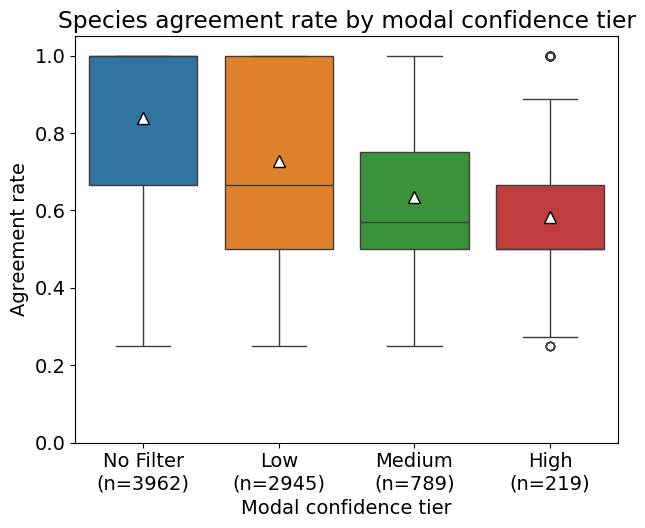

In [23]:
### Boxplot: agreement rate by modal confidence tier
agreement_plot_df = activity_agreement_df.to_pandas()

agreement_plot_df = agreement_plot_df.dropna(subset=['modal_tier', 'agreement_rate'])
agreement_plot_df['modal_tier'] = agreement_plot_df['modal_tier'].replace({'No Prediction': 'No Filter'})
tier_order = ['No Filter', 'Low', 'Medium', 'High']
agreement_plot_df = agreement_plot_df[agreement_plot_df['modal_tier'].isin(tier_order)].copy()
tier_count_map = agreement_plot_df['modal_tier'].value_counts().to_dict()

plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(
    data=agreement_plot_df,
    x='modal_tier',
    y='agreement_rate',
    order=tier_order,
    hue='modal_tier',
    hue_order=tier_order,
    dodge=False,
    showfliers=True,
    showmeans=True,
    meanprops={
        'marker': '^',
        'markerfacecolor': 'white',
        'markeredgecolor': 'black',
        'markersize': 8,
    },
    legend=False,
 )

ax.set_xticklabels([f'{tier}\n(n={tier_count_map.get(tier, 0)})' for tier in tier_order])
ax.set_xlabel('Modal confidence tier')
ax.set_ylabel('Agreement rate')
ax.set_title('Species agreement rate by modal confidence tier')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

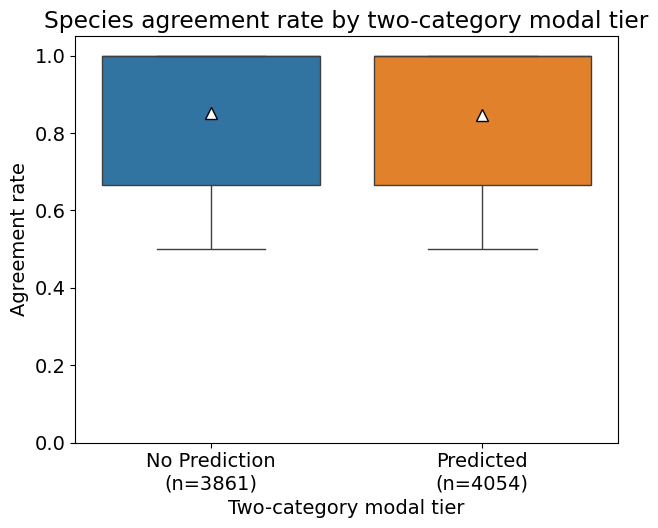

In [24]:
### Boxplot: agreement rate by No Prediction vs Predicted
agreement_plot_df = two_category_agreement_df.to_pandas()

agreement_plot_df = agreement_plot_df.dropna(subset=['modal_tier', 'agreement_rate'])
tier_order = ['No Prediction', 'Predicted']
agreement_plot_df = agreement_plot_df[agreement_plot_df['modal_tier'].isin(tier_order)].copy()
tier_count_map = agreement_plot_df['modal_tier'].value_counts().to_dict()

plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(
    data=agreement_plot_df,
    x='modal_tier',
    y='agreement_rate',
    order=tier_order,
    hue='modal_tier',
    hue_order=tier_order,
    dodge=False,
    showfliers=True,
    showmeans=True,
    meanprops={
        'marker': '^',
        'markerfacecolor': 'white',
        'markeredgecolor': 'black',
        'markersize': 8,
    },
    legend=False,
)

ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels([f'{tier}\n(n={tier_count_map.get(tier, 0)})' for tier in tier_order])
ax.set_xlabel('Two-category modal tier')
ax.set_ylabel('Agreement rate')
ax.set_title('Species agreement rate by two-category modal tier')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

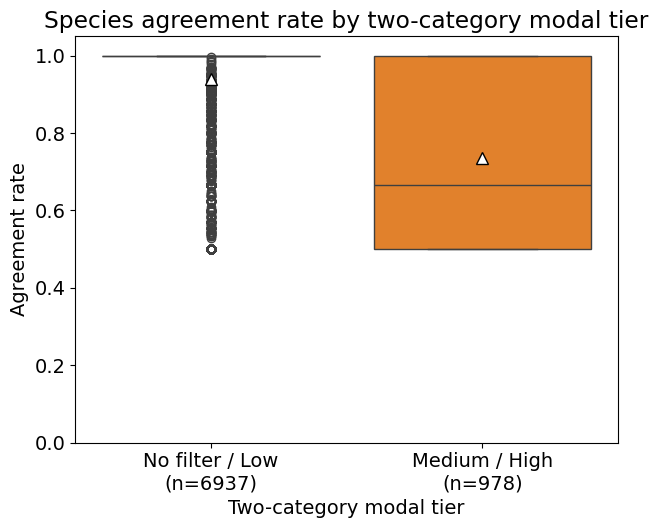

In [25]:
### Boxplot: agreement rate by No/Low vs Medium/High
agreement_plot_df2 = two_category_agreement2_df.to_pandas()

agreement_plot_df2 = agreement_plot_df2.dropna(subset=['modal_tier', 'agreement_rate'])
tier_order = ['No filter / Low', 'Medium / High']
agreement_plot_df2 = agreement_plot_df2[agreement_plot_df2['modal_tier'].isin(tier_order)].copy()
tier_count_map = agreement_plot_df2['modal_tier'].value_counts().to_dict()

plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(
    data=agreement_plot_df2,
    x='modal_tier',
    y='agreement_rate',
    order=tier_order,
    hue='modal_tier',
    hue_order=tier_order,
    dodge=False,
    showfliers=True,
    showmeans=True,
    meanprops={
        'marker': '^',
        'markerfacecolor': 'white',
        'markeredgecolor': 'black',
        'markersize': 8,
    },
    legend=False,
)

ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels([f'{tier}\n(n={tier_count_map.get(tier, 0)})' for tier in tier_order])
ax.set_xlabel('Two-category modal tier')
ax.set_ylabel('Agreement rate')
ax.set_title('Species agreement rate by two-category modal tier')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Prevalence

In [26]:
print("Number of CF metagenomes with >= 1 UHVDB species:", cf_metag_all_data.select(pl.col('sample_id').n_unique()).item())

Number of CF metagenomes with >= 1 UHVDB species: 1789


In [27]:
### Prevalence by top confidence tier
tier_rank_expr = (
    pl.when(pl.col('hybrid_confidence_tier') == 'High').then(pl.lit(3))
      .when(pl.col('hybrid_confidence_tier') == 'Medium').then(pl.lit(2))
      .when(pl.col('hybrid_confidence_tier') == 'Low').then(pl.lit(1))
      .otherwise(pl.lit(0))
 )

tier_label_expr = (
    pl.when(pl.col('top_confidence_rank') == 3).then(pl.lit('High'))
      .when(pl.col('top_confidence_rank') == 2).then(pl.lit('Medium'))
      .when(pl.col('top_confidence_rank') == 1).then(pl.lit('Low'))
      .otherwise(pl.lit('No Prediction'))
 )

species_prevalence_by_top_confidence = (
    cf_metag_all_data
        .select(['species_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .drop_nulls(['species_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .with_columns([
            tier_rank_expr.alias('tier_rank'),
        ])
        .group_by('species_cluster_id')
        .agg([
            pl.col('sample_id').n_unique().alias('n_samples_detected'),
            pl.col('tier_rank').max().alias('top_confidence_rank'),
        ])
        .with_columns([
            tier_label_expr.alias('top_confidence_tier'),
            (pl.col('n_samples_detected') * 100 / cf_metag_all_data.select(pl.col('sample_id').n_unique()).item()).alias('prevalence'),
        ])
 )

prevalence_summary_by_top_confidence = (
    species_prevalence_by_top_confidence
        .group_by('top_confidence_tier')
        .agg([
            pl.len().alias('n_species'),
            pl.col('prevalence').mean().alias('mean_prevalence'),
            pl.col('prevalence').median().alias('median_prevalence'),
            pl.col('prevalence').max().alias('max_prevalence'),
            pl.col('prevalence').min().alias('min_prevalence'),
        ])
        .with_columns([
            pl.col('top_confidence_tier').replace({
                'High': 3,
                'Medium': 2,
                'Low': 1,
                'No Prediction': 0,
            }).alias('sort_rank')
        ])
        .sort('sort_rank', descending=True)
        .drop('sort_rank')
 )

/tmp/ipykernel_41654/1914410900.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


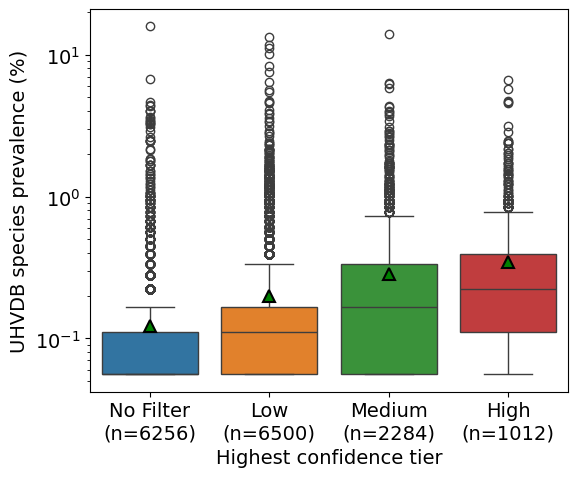

In [28]:
### Boxplot of species prevalence by top confidence tier
boxplot_df = species_prevalence_by_top_confidence.to_pandas()
boxplot_df['top_confidence_tier'] = boxplot_df['top_confidence_tier'].replace({'No Prediction': 'No Filter'})
species_count_map = boxplot_df['top_confidence_tier'].value_counts().to_dict()

plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=boxplot_df,
    x='top_confidence_tier',
    y='prevalence',
    hue='top_confidence_tier',
    order=['No Filter', 'Low', 'Medium', 'High'],
    hue_order=['No Filter', 'Low', 'Medium', 'High'],
    dodge=False,
    showfliers=True,
    showmeans=True,
    meanprops={
        'marker': '^',
        'markerfacecolor': 'green',
        'markeredgecolor': 'black',
        'markersize': 9,
        'markeredgewidth': 1.5,
    },
    legend=False,
)
ax.set_xticklabels([
    f'{tier}\n(n={species_count_map.get(tier, 0)})'
    for tier in ['No Filter', 'Low', 'Medium', 'High']
])

# sns.stripplot(
#     data=boxplot_df,
#     x='top_confidence_tier',
#     y='prevalence',
#     order=['High', 'Medium', 'Low', 'No Filter'],
#     color='black',
#     alpha=0.25,
#     size=2.5,
#     jitter=0.25,
#     ax=ax,
#  )

ax.set_xlabel('Highest confidence tier')
ax.set_ylabel('UHVDB species prevalence (%)')
plt.yscale('log')
plt.tight_layout()
plt.show()

Genus-cluster prevalence summary by top confidence tier:


/tmp/ipykernel_41654/314093749.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


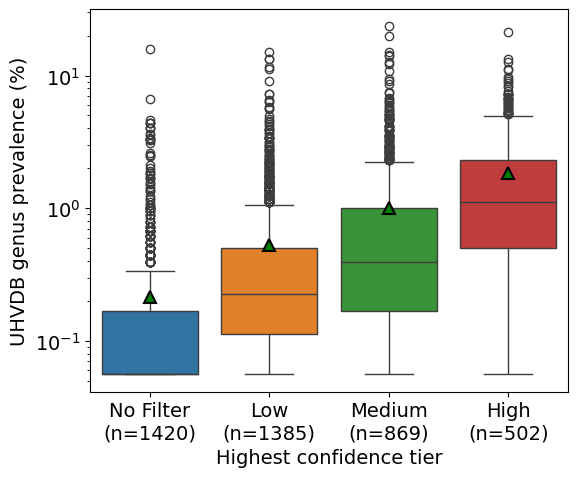

In [29]:
### Prevalence by top confidence tier using most_common_genus_cluster_id
genus_prevalence_input = (
    cf_metag_all_data
        .select(['most_common_genus_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .drop_nulls(['most_common_genus_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
 )

genus_prevalence_by_top_confidence = (
    genus_prevalence_input
        .with_columns([
            pl.when(pl.col('hybrid_confidence_tier') == 'High').then(pl.lit(3))
              .when(pl.col('hybrid_confidence_tier') == 'Medium').then(pl.lit(2))
              .when(pl.col('hybrid_confidence_tier') == 'Low').then(pl.lit(1))
              .otherwise(pl.lit(0))
              .alias('tier_rank'),
        ])
        .group_by('most_common_genus_cluster_id')
        .agg([
            pl.col('sample_id').n_unique().alias('n_samples_detected'),
            pl.col('tier_rank').max().alias('top_confidence_rank'),
        ])
        .with_columns([
            pl.when(pl.col('top_confidence_rank') == 3).then(pl.lit('High'))
              .when(pl.col('top_confidence_rank') == 2).then(pl.lit('Medium'))
              .when(pl.col('top_confidence_rank') == 1).then(pl.lit('Low'))
              .otherwise(pl.lit('No Filter'))
              .alias('top_confidence_tier'),
            (pl.col('n_samples_detected') * 100 / cf_metag_all_data.select(pl.col('sample_id').n_unique()).item()).alias('prevalence'),
        ])
 )

genus_prevalence_summary_by_top_confidence = (
    genus_prevalence_by_top_confidence
        .group_by('top_confidence_tier')
        .agg([
            pl.len().alias('n_genus_clusters'),
            pl.col('prevalence').mean().alias('mean_prevalence'),
            pl.col('prevalence').median().alias('median_prevalence'),
            pl.col('prevalence').max().alias('max_prevalence'),
            pl.col('prevalence').min().alias('min_prevalence'),
        ])
        .with_columns([
            pl.col('top_confidence_tier').replace({
                'High': 3,
                'Medium': 2,
                'Low': 1,
                'No Prediction': 0,
            }).alias('sort_rank')
        ])
        .sort('sort_rank', descending=True)
        .drop('sort_rank')
 )

print('Genus-cluster prevalence summary by top confidence tier:')
genus_prevalence_summary_by_top_confidence

genus_boxplot_df = genus_prevalence_by_top_confidence.to_pandas()
genus_boxplot_df['top_confidence_tier'] = genus_boxplot_df['top_confidence_tier']
genus_count_map = dict(zip(genus_prevalence_summary_by_top_confidence['top_confidence_tier'].to_list(), genus_prevalence_summary_by_top_confidence['n_genus_clusters'].to_list()))

plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=genus_boxplot_df,
    x='top_confidence_tier',
    y='prevalence',
    hue='top_confidence_tier',
    order=['No Filter', 'Low', 'Medium', 'High'],
    hue_order=['No Filter', 'Low', 'Medium', 'High'],
    dodge=False,
    showfliers=True,
    showmeans=True,
    meanprops={
        'marker': '^',
        'markerfacecolor': 'green',
        'markeredgecolor': 'black',
        'markersize': 9,
        'markeredgewidth': 1.5,
    },
    legend=False
)
ax.set_xticklabels([
    f'{tier}\n(n={genus_count_map.get(tier, 0)})'
    for tier in ['No Filter', 'Low', 'Medium', 'High']
])

ax.set_xlabel('Highest confidence tier')
ax.set_ylabel('UHVDB genus prevalence (%)')
plt.yscale('log')
plt.tight_layout()
plt.show()

Family-cluster prevalence summary by top confidence tier:


/tmp/ipykernel_41654/4182329915.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


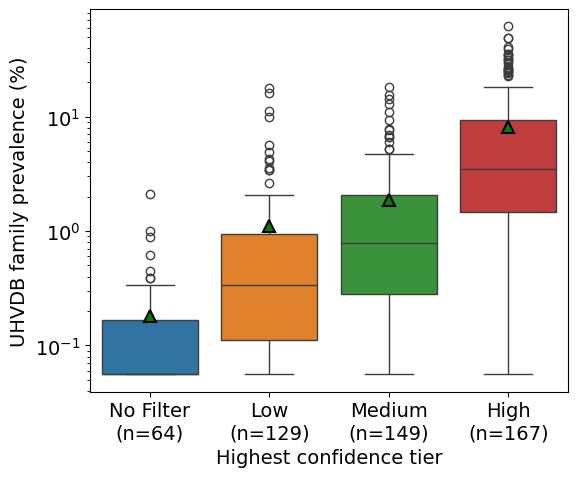

In [30]:
### Prevalence by top confidence tier using most_common_family_cluster_id
family_prevalence_input = (
    cf_metag_all_data
        .select(['most_common_family_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
        .drop_nulls(['most_common_family_cluster_id', 'sample_id', 'hybrid_confidence_tier'])
 )

family_prevalence_by_top_confidence = (
    family_prevalence_input
        .with_columns([
            pl.when(pl.col('hybrid_confidence_tier') == 'High').then(pl.lit(3))
              .when(pl.col('hybrid_confidence_tier') == 'Medium').then(pl.lit(2))
              .when(pl.col('hybrid_confidence_tier') == 'Low').then(pl.lit(1))
              .otherwise(pl.lit(0))
              .alias('tier_rank'),
        ])
        .group_by('most_common_family_cluster_id')
        .agg([
            pl.col('sample_id').n_unique().alias('n_samples_detected'),
            pl.col('tier_rank').max().alias('top_confidence_rank'),
        ])
        .with_columns([
            pl.when(pl.col('top_confidence_rank') == 3).then(pl.lit('High'))
              .when(pl.col('top_confidence_rank') == 2).then(pl.lit('Medium'))
              .when(pl.col('top_confidence_rank') == 1).then(pl.lit('Low'))
              .otherwise(pl.lit('No Filter'))
              .alias('top_confidence_tier'),
            (pl.col('n_samples_detected') * 100 / cf_metag_all_data.select(pl.col('sample_id').n_unique()).item()).alias('prevalence'),
        ])
 )

family_prevalence_summary_by_top_confidence = (
    family_prevalence_by_top_confidence
        .group_by('top_confidence_tier')
        .agg([
            pl.len().alias('n_family_clusters'),
            pl.col('prevalence').mean().alias('mean_prevalence'),
            pl.col('prevalence').median().alias('median_prevalence'),
            pl.col('prevalence').max().alias('max_prevalence'),
            pl.col('prevalence').min().alias('min_prevalence'),
        ])
        .with_columns([
            pl.col('top_confidence_tier').replace({
                'High': 3,
                'Medium': 2,
                'Low': 1,
                'No Filter': 0,
            }).alias('sort_rank')
        ])
        .sort('sort_rank', descending=True)
        .drop('sort_rank')
 )

print('Family-cluster prevalence summary by top confidence tier:')
family_prevalence_summary_by_top_confidence

family_boxplot_df = family_prevalence_by_top_confidence.to_pandas()
family_boxplot_df['top_confidence_tier'] = family_boxplot_df['top_confidence_tier']
family_count_map = dict(zip(family_prevalence_summary_by_top_confidence['top_confidence_tier'].to_list(), family_prevalence_summary_by_top_confidence['n_family_clusters'].to_list()))


plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=family_boxplot_df,
    x='top_confidence_tier',
    y='prevalence',
    hue='top_confidence_tier',
    order=['No Filter', 'Low', 'Medium', 'High'],
    hue_order=['No Filter', 'Low', 'Medium', 'High'],
    dodge=False,
    showfliers=True,
    showmeans=True,
    meanprops={
        'marker': '^',
        'markerfacecolor': 'green',
        'markeredgecolor': 'black',
        'markersize': 9,
        'markeredgewidth': 1.5,
    },
    legend=False
)
ax.set_xticklabels([
    f'{tier}\n(n={family_count_map.get(tier, 0)})'
    for tier in ['No Filter', 'Low', 'Medium', 'High']
])
ax.set_xlabel('Highest confidence tier')
ax.set_ylabel('UHVDB family prevalence (%)')
plt.yscale('log')
plt.tight_layout()
plt.show()

# Annotations

In [31]:
### Species-level top confidence tier with retained metadata
# Build a species-level table from `cf_metag_all_data` while preserving key metadata fields.

tier_rank_expr = (
    pl.when(pl.col('hybrid_confidence_tier') == 'High').then(pl.lit(3))
      .when(pl.col('hybrid_confidence_tier') == 'Medium').then(pl.lit(2))
      .when(pl.col('hybrid_confidence_tier') == 'Low').then(pl.lit(1))
      .otherwise(pl.lit(0))
)

species_top_tier_with_metadata = (
    cf_metag_all_data
        .with_columns([
            tier_rank_expr.alias('tier_rank')
        ])
        .group_by('species_cluster_id')
        .agg([
            pl.col('sample_id').n_unique().alias('n_samples_detected'),
            (pl.col('tier_rank') > 0).sum().alias('n_samples_predicted'),
            pl.col('tier_rank').max().alias('top_confidence_rank'),
        ])
        .with_columns([
            pl.when(pl.col('top_confidence_rank') == 3).then(pl.lit('High'))
              .when(pl.col('top_confidence_rank') == 2).then(pl.lit('Medium'))
              .when(pl.col('top_confidence_rank') == 1).then(pl.lit('Low'))
              .otherwise(pl.lit('No Filter'))
              .alias('top_confidence_tier'),
            (pl.col('n_samples_detected') * 100 / cf_metag_all_data.select(pl.col('sample_id').n_unique()).item()).alias('prevalence_pct'),
        ])
        .sort(['top_confidence_rank', 'n_samples_detected'], descending=[True, True])
)

print('Species with assigned top confidence tier:', species_top_tier_with_metadata.unique('species_cluster_id').height)

Species with assigned top confidence tier: 16052


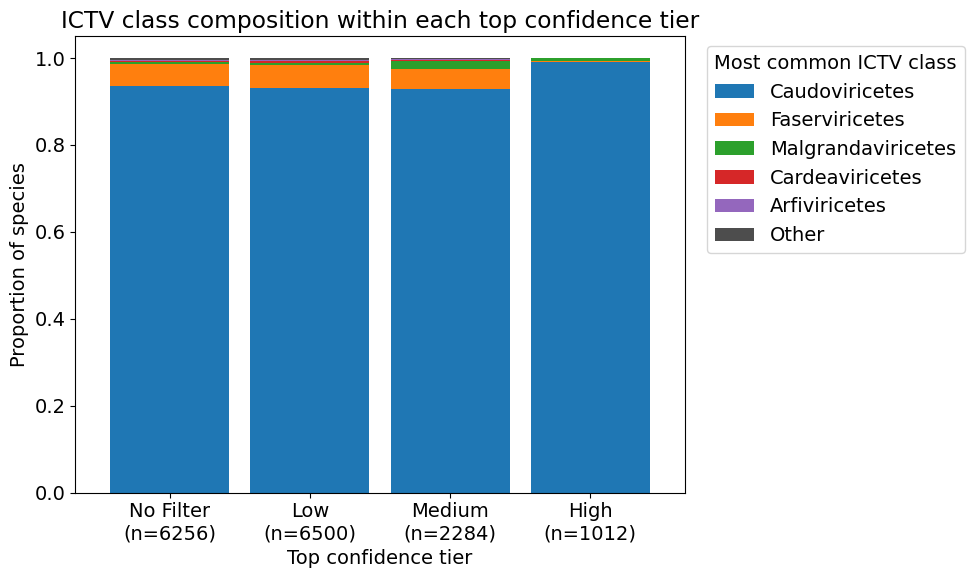

In [32]:
### Stacked bar chart: ICTV class composition within each top confidence tier
ictv_bar_df = (
    cf_metag_all_data
        .join(species_top_tier_with_metadata[['species_cluster_id', 'top_confidence_tier']], on='species_cluster_id', how='inner')
        .unique('species_cluster_id')
        .select(['most_common_ictv_class', 'top_confidence_tier'])
        .drop_nulls(['most_common_ictv_class', 'top_confidence_tier'])
        .to_pandas()
)

# Normalize possible list/array values coming from mode() aggregations
def _to_scalar(v):
    if isinstance(v, (list, tuple, np.ndarray, pd.Series)):
        return v[0] if len(v) > 0 else np.nan
    return v

ictv_bar_df['most_common_ictv_class'] = ictv_bar_df['most_common_ictv_class'].apply(_to_scalar)
ictv_bar_df = ictv_bar_df.dropna(subset=['most_common_ictv_class', 'top_confidence_tier'])

# Keep only the 5 most prevalent ICTV classes and collapse the rest into Other
class_counts = ictv_bar_df['most_common_ictv_class'].value_counts()
top_5_classes = class_counts.head(5).index.tolist()
ictv_bar_df['ictv_class_plot'] = np.where(
    ictv_bar_df['most_common_ictv_class'].isin(top_5_classes),
    ictv_bar_df['most_common_ictv_class'],
    'Other',
)

# Stable tier order and readable class order
tier_order = ['No Filter', 'Low', 'Medium', 'High']
tier_count_map = ictv_bar_df['top_confidence_tier'].value_counts().to_dict()
class_order = top_5_classes + ['Other']

# Proportion of ICTV classes within each top confidence tier
ictv_props = (
    pd.crosstab(
        ictv_bar_df['top_confidence_tier'],
        ictv_bar_df['ictv_class_plot'],
        normalize='index',
    )
    .reindex(index=tier_order, columns=class_order, fill_value=0)
)

palette = sns.color_palette('tab10', n_colors=len(top_5_classes))
color_map = {'Other': '#4d4d4d'}
for cls, color in zip(top_5_classes, palette):
    color_map[cls] = color
stack_colors = [color_map.get(col, '#cccccc') for col in class_order]

ax = ictv_props.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=stack_colors,
    width=0.85,
)

ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels([f'{tier}\n(n={tier_count_map.get(tier, 0)})' for tier in tier_order])
ax.set_xlabel('Top confidence tier')
ax.set_ylabel('Proportion of species')
ax.set_title('ICTV class composition within each top confidence tier')
plt.xticks(rotation=0)
plt.legend(title='Most common ICTV class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

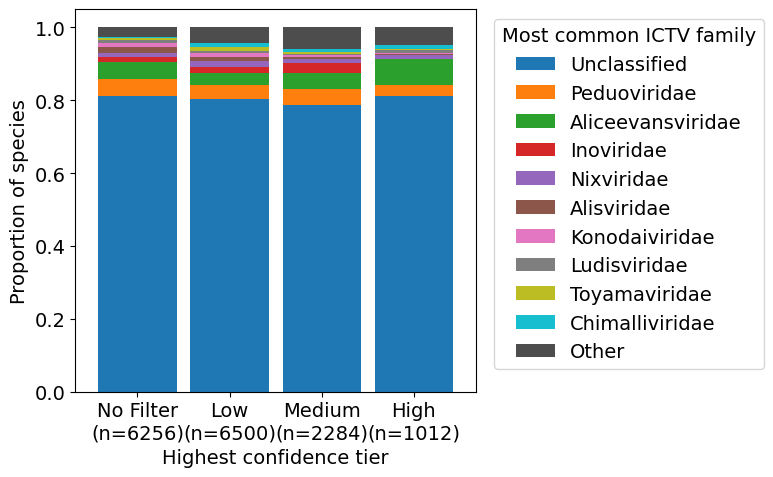

In [33]:
### Stacked bar chart: ICTV class composition within each top confidence tier
ictv_bar_df = (
    cf_metag_all_data
        .join(species_top_tier_with_metadata[['species_cluster_id', 'top_confidence_tier']], on='species_cluster_id', how='inner')
        .unique('species_cluster_id')
        .select(['most_common_ictv_family', 'top_confidence_tier'])
        .drop_nulls(['most_common_ictv_family', 'top_confidence_tier'])
        .to_pandas()
)

# Normalize possible list/array values coming from mode() aggregations
def _to_scalar(v):
    if isinstance(v, (list, tuple, np.ndarray, pd.Series)):
        return v[0] if len(v) > 0 else np.nan
    return v

ictv_bar_df['most_common_ictv_family'] = ictv_bar_df['most_common_ictv_family'].apply(_to_scalar)
ictv_bar_df = ictv_bar_df.dropna(subset=['most_common_ictv_family', 'top_confidence_tier'])

# Keep only the 5 most prevalent ICTV classes and collapse the rest into Other
class_counts = ictv_bar_df['most_common_ictv_family'].value_counts()
top_5_classes = class_counts.head(10).index.tolist()
ictv_bar_df['ictv_class_plot'] = np.where(
    ictv_bar_df['most_common_ictv_family'].isin(top_5_classes),
    ictv_bar_df['most_common_ictv_family'],
    'Other',
)

# Stable tier order and readable class order
tier_order = ['No Filter', 'Low', 'Medium', 'High']
tier_count_map = ictv_bar_df['top_confidence_tier'].value_counts().to_dict()
class_order = top_5_classes + ['Other']

# Proportion of ICTV classes within each top confidence tier
ictv_props = (
    pd.crosstab(
        ictv_bar_df['top_confidence_tier'],
        ictv_bar_df['ictv_class_plot'],
        normalize='index',
    )
    .reindex(index=tier_order, columns=class_order, fill_value=0)
)

palette = sns.color_palette('tab10', n_colors=len(top_5_classes))
color_map = {'Other': '#4d4d4d'}
for cls, color in zip(top_5_classes, palette):
    color_map[cls] = color
stack_colors = [color_map.get(col, '#cccccc') for col in class_order]

ax = ictv_props.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=stack_colors,
    width=0.85,
)

ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels([f'{tier}\n(n={tier_count_map.get(tier, 0)})' for tier in tier_order])
ax.set_xlabel('Highest confidence tier')
ax.set_ylabel('Proportion of species')
plt.xticks(rotation=0)
plt.legend(title='Most common ICTV family', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

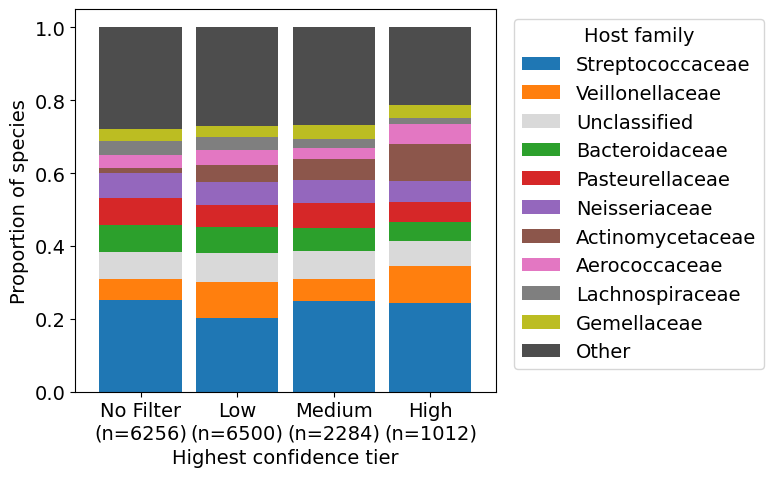

In [34]:
### Stacked bar chart: host family composition within each top confidence tier
host_bar_df = (
    cf_metag_all_data
        .join(species_top_tier_with_metadata[['species_cluster_id', 'top_confidence_tier']], on='species_cluster_id', how='inner')
        .unique('species_cluster_id')
        .select(['most_common_host_taxonomy', 'top_confidence_tier'])
        .drop_nulls(['most_common_host_taxonomy', 'top_confidence_tier'])
        .to_pandas()
)

# Normalize possible list/array values coming from mode() aggregations
def _to_scalar(v):
    if isinstance(v, (list, tuple, np.ndarray, pd.Series)):
        return v[0] if len(v) > 0 else np.nan
    return v

host_bar_df['most_common_host_taxonomy'] = host_bar_df['most_common_host_taxonomy'].apply(_to_scalar)

# Extract the host family from the taxonomy string if present; otherwise keep the original label
host_bar_df['host_family'] = (
    host_bar_df['most_common_host_taxonomy']
        .astype(str)
        .str.extract(r'(f__[^;|]+)', expand=False)
        .str.replace('f__', '', regex=False)
)
host_bar_df['host_family'] = host_bar_df['host_family'].replace({'nan': np.nan}).fillna('Unclassified')
host_bar_df = host_bar_df.dropna(subset=['top_confidence_tier'])

# Collapse everything outside the top 10 families into Other
family_counts = host_bar_df['host_family'].value_counts()
top_10_families = family_counts.head(10).index.tolist()
host_bar_df['host_family'] = np.where(
    host_bar_df['host_family'].isin(top_10_families),
    host_bar_df['host_family'],
    'Other',
)

# Stable tier order and readable host order
tier_order = ['No Filter', 'Low', 'Medium', 'High']
tier_count_map = host_bar_df['top_confidence_tier'].value_counts().to_dict()
host_order = top_10_families + ['Other']

# Proportion of host families within each top confidence tier
host_props = (
    pd.crosstab(
        host_bar_df['top_confidence_tier'],
        host_bar_df['host_family'],
        normalize='index',
    )
    .reindex(index=tier_order, columns=host_order, fill_value=0)
)

family_palette = sns.color_palette('tab10', n_colors=len([f for f in top_10_families if f not in ['Unclassified']]))
color_map = {'Other': '#4d4d4d', 'Unclassified': '#d9d9d9'}
for fam, color in zip([f for f in top_10_families if f not in ['Unclassified']], family_palette):
    color_map[fam] = color
palette = [color_map.get(col, '#cccccc') for col in host_order]

ax = host_props.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=palette,
    width=0.85,
)

ax.set_xticklabels([f'{tier}\n(n={tier_count_map.get(tier, 0)})' for tier in tier_order])
ax.set_xlabel('Highest confidence tier')
ax.set_ylabel('Proportion of species')
plt.xticks(rotation=0)
plt.legend(title='Host family', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

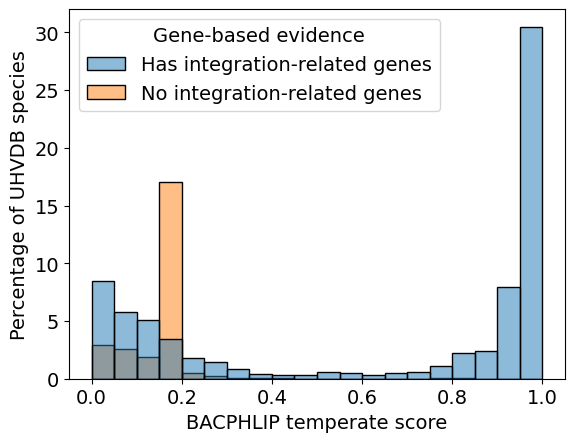

In [35]:
uhvdb_species_annotations = (
    uhvdb_final_metadata[['seq_name', 'seqhash_rep', 'uhvdb_id', 'checkv_quality', 'genomovar_rep', 'species_cluster_id', 'family_cluster_id', 'genus_cluster_id', 'host_lineage', 'ictv_class', 'temperate', 'integration_status', 'phrog_integration_excision', 'empathi_integration']]
        .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
        .filter(pl.col('uhvdb_id') == pl.col('genomovar_rep'))
        .group_by(['species_cluster_id'])
        .agg([
            pl.len().alias('num_genomovars_in_species'),
            pl.col('ictv_class').mode().first().alias('most_common_ictv_class'),
            pl.col('family_cluster_id').mode().first().alias('most_common_uhvdb_family'),
            pl.col('genus_cluster_id').mode().first().alias('most_common_uhvdb_genus'),
            pl.col('host_lineage').mode().first().alias('most_common_host_lineage'),
            pl.col('temperate').median().alias('med_temperate_score'),
            pl.col('temperate').mean().alias('mean_temperate_score'),
            ((pl.col('phrog_integration_excision') > 0) | (pl.col('empathi_integration') > 0)).sum().alias('count_integration_related'),
            (pl.col('integration_status') == 'integrated').sum().alias('count_integrated'),
            (pl.col('checkv_quality') == 'Complete').sum().alias('count_complete'),
        ])
        .with_columns([
            (pl.col('count_integration_related')/pl.col('num_genomovars_in_species')).alias('prop_integration_related'),
            (pl.col('count_integrated')/pl.col('num_genomovars_in_species')).alias('prop_integrated'),
        ])
        .with_columns([
            pl.when(pl.col('prop_integration_related') >= 0.5).then(pl.lit('Has integration-related genes')).otherwise(pl.lit('No integration-related genes')).alias('Gene-based evidence'),
        ])
        .filter(pl.col('count_complete') >= 1)
)

sns.histplot(
    data=uhvdb_species_annotations,
    hue='Gene-based evidence',
    x='med_temperate_score',
    bins=20,
    stat='percent'
    # kde=True
)
plt.xlabel('BACPHLIP temperate score')
plt.ylabel('Percentage of UHVDB species')
plt.show()

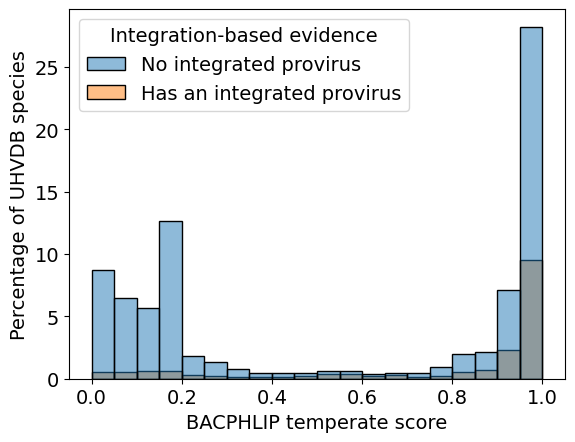

In [36]:
uhvdb_species_annotations = (
    uhvdb_final_metadata[['seq_name', 'seqhash_rep', 'uhvdb_id', 'checkv_quality', 'genomovar_rep', 'species_cluster_id', 'family_cluster_id', 'genus_cluster_id', 'host_lineage', 'ictv_class', 'temperate', 'integration_status', 'phrog_integration_excision', 'empathi_integration']]
        .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
        .filter(pl.col('uhvdb_id') == pl.col('genomovar_rep'))
        .group_by(['species_cluster_id'])
        .agg([
            pl.len().alias('num_genomovars_in_species'),
            pl.col('ictv_class').mode().first().alias('most_common_ictv_class'),
            pl.col('family_cluster_id').mode().first().alias('most_common_uhvdb_family'),
            pl.col('genus_cluster_id').mode().first().alias('most_common_uhvdb_genus'),
            pl.col('host_lineage').mode().first().alias('most_common_host_lineage'),
            pl.col('temperate').median().alias('med_temperate_score'),
            pl.col('temperate').mean().alias('mean_temperate_score'),
            ((pl.col('phrog_integration_excision') > 0) | (pl.col('empathi_integration') > 0)).sum().alias('count_integration_related'),
            (pl.col('integration_status') == 'integrated').sum().alias('count_integrated'),
            (pl.col('checkv_quality') == 'Complete').sum().alias('count_complete'),
        ])
        .with_columns([
            (pl.col('count_integration_related')/pl.col('num_genomovars_in_species')).alias('prop_integration_related'),
            (pl.col('count_integrated')/pl.col('num_genomovars_in_species')).alias('prop_integrated'),
        ])
        .with_columns([
            pl.when(pl.col('prop_integrated') >= 0.5).then(pl.lit('Has an integrated provirus')).otherwise(pl.lit('No integrated provirus')).alias('Integration-based evidence'),
        ])
        # .filter(pl.col('count_complete') >= 1)
)

sns.histplot(
    data=uhvdb_species_annotations,
    hue='Integration-based evidence',
    x='med_temperate_score',
    bins=20,
    stat='percent'
    # kde=True
)
plt.xlabel('BACPHLIP temperate score')
plt.ylabel('Percentage of UHVDB species')
plt.show()

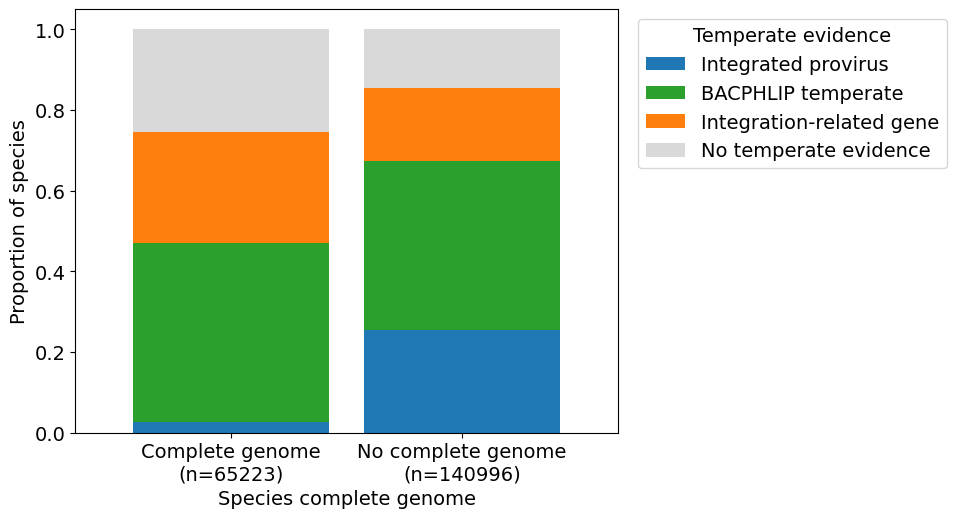

In [37]:
uhvdb_species_annotations = (
    uhvdb_final_metadata[['seq_name', 'seqhash_rep', 'uhvdb_id', 'checkv_quality', 'genomovar_rep', 'species_cluster_id', 'family_cluster_id', 'genus_cluster_id', 'host_lineage', 'ictv_class', 'temperate', 'integration_status', 'phrog_integration_excision', 'empathi_integration']]
        .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
        .filter(pl.col('uhvdb_id') == pl.col('genomovar_rep'))
        .group_by(['species_cluster_id'])
        .agg([
            pl.len().alias('num_genomovars_in_species'),
            pl.col('ictv_class').mode().first().alias('most_common_ictv_class'),
            pl.col('family_cluster_id').mode().first().alias('most_common_uhvdb_family'),
            pl.col('genus_cluster_id').mode().first().alias('most_common_uhvdb_genus'),
            pl.col('host_lineage').mode().first().alias('most_common_host_lineage'),
            pl.col('temperate').median().alias('med_temperate_score'),
            pl.col('temperate').mean().alias('mean_temperate_score'),
            ((pl.col('phrog_integration_excision') > 0) | (pl.col('empathi_integration') > 0)).sum().alias('count_integration_related'),
            (pl.col('integration_status') == 'integrated').sum().alias('count_integrated'),
            (pl.col('checkv_quality') == 'Complete').sum().alias('count_complete'),
        ])
        .with_columns([
            (pl.col('count_integration_related')/pl.col('num_genomovars_in_species')).alias('prop_integration_related'),
            (pl.col('count_integrated')/pl.col('num_genomovars_in_species')).alias('prop_integrated'),
        ])
        .with_columns([
            pl.when(pl.col('prop_integrated') >= 0.5).then(pl.lit('Integrated provirus'))
                .when(pl.col('med_temperate_score') > 0.5).then(pl.lit('BACPHLIP temperate'))
                .when(pl.col('prop_integration_related') > 0.5).then(pl.lit('Integration-related gene'))
                .otherwise(pl.lit('No temperate evidence')).alias('Temperate evidence'),
            pl.when(pl.col('count_complete') >= 1).then(pl.lit('Complete genome'))
                .otherwise(pl.lit('No complete genome'))
                .alias('Species complete genome')
        ])
)

# Stacked bar chart: Temperate evidence split by species complete-genome status
temperate_bar_df = uhvdb_species_annotations.to_pandas()

evidence_order = [
    'Integrated provirus',
    'BACPHLIP temperate',
    'Integration-related gene',
    'No temperate evidence',
]
genome_order = ['Complete genome', 'No complete genome']

genome_count_map = temperate_bar_df['Species complete genome'].value_counts().to_dict()
temperate_props = (
    pd.crosstab(
        temperate_bar_df['Species complete genome'],
        temperate_bar_df['Temperate evidence'],
        normalize='index',
    )
    .reindex(index=genome_order, columns=evidence_order, fill_value=0)
)

temperate_color_map = {
    'Integrated provirus': '#1f77b4',
    'BACPHLIP temperate': '#2ca02c',
    'Integration-related gene': '#ff7f0e',
    'No temperate evidence': '#d9d9d9',
}

ax = temperate_props.plot(
    kind='bar',
    stacked=True,
    figsize=(7, 5.5),
    width=0.85,
    color=[temperate_color_map[x] for x in evidence_order],
)

ax.set_xticks(range(len(genome_order)))
ax.set_xticklabels([f"{x}\n(n={genome_count_map.get(x, 0)})" for x in genome_order])
ax.set_xlabel('Species complete genome')
ax.set_ylabel('Proportion of species')
plt.xticks(rotation=0)
plt.legend(title='Temperate evidence', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

In [38]:
(
    cf_metag_all_data
        .join(species_top_tier_with_metadata[['species_cluster_id', 'top_confidence_tier']], on='species_cluster_id', how='inner')
        .unique('species_cluster_id')
        .with_columns([
            (pl.col('count_integration_related')/pl.col('num_genomovars_in_species')).alias('prop_integration_related'),
            (pl.col('count_integrated')/pl.col('num_genomovars_in_species')).alias('prop_integrated'),
        ])
        # .filter(pl.col('top_confidence_tier').is_in(['Medium', 'High']))
        .filter(pl.col('prop_integrated') < 0.5)
        .filter(pl.col('prop_integration_related') < 0.5)
        .filter(pl.col('med_temperate_score') < 0.5)
        .filter(pl.col('count_complete') >= 1)
        .height
)

194

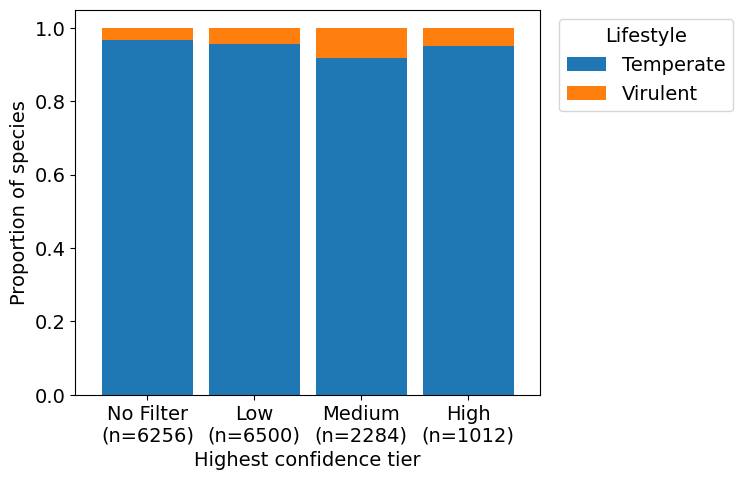

In [39]:
### Stacked bar chart: lifestyle composition within each top confidence tier
lifestyle_df = (
    cf_metag_all_data
        .join(species_top_tier_with_metadata[['species_cluster_id', 'top_confidence_tier']], on='species_cluster_id', how='inner')
        .unique('species_cluster_id')
        .fill_null(0)
        .with_columns([
            (pl.col('count_integration_related')/pl.col('num_genomovars_in_species')).alias('prop_integration_related'),
            (pl.col('count_integrated')/pl.col('num_genomovars_in_species')).alias('prop_integrated'),
        ])
        .with_columns([
            pl.when((pl.col('prop_integrated') > 0.5))
              .then(pl.lit('Temperate'))
              .when(pl.col('med_temperate_score') > 0.5)
              .then(pl.lit('Temperate'))
              .when(pl.col('prop_integration_related') >= 0.5)
              .then(pl.lit('Temperate'))
              .otherwise(pl.lit('Virulent'))
              .alias('lifestyle')
        ])
        .select(['top_confidence_tier', 'lifestyle'])
        .to_pandas()
)

tier_order = ['No Filter', 'Low', 'Medium', 'High']
lifestyle_order = ['Temperate', 'Virulent']
tier_count_map = lifestyle_df['top_confidence_tier'].value_counts().to_dict()

lifestyle_props = (
    pd.crosstab(
        lifestyle_df['top_confidence_tier'],
        lifestyle_df['lifestyle'],
        normalize='index',
    )
    .reindex(index=tier_order, columns=lifestyle_order, fill_value=0)
)

ax = lifestyle_props.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 5),
    width=0.85,
)

ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels([f'{tier}\n(n={tier_count_map.get(tier, 0)})' for tier in tier_order])
ax.set_xlabel('Highest confidence tier')
ax.set_ylabel('Proportion of species')
plt.xticks(rotation=0)
plt.legend(title='Lifestyle', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

# Phage-bacteria dynamics

In [40]:
print("Total phage detections:", cf_metag_all_data.height)
print("Phage detections with predicted host:", cf_metag_all_data.filter(pl.col('most_common_host_taxonomy') != None).height)
print("Number of phage detections with predicted host genus:",
    cf_metag_all_data
        .with_columns(pl.col('most_common_host_taxonomy'))
        .filter(pl.col('most_common_host_taxonomy').str.contains('g__'))
        .height
)
print("Number of phage detections with predicted host species:",
    cf_metag_all_data
        .with_columns(pl.col('most_common_host_taxonomy'))
        .filter(pl.col('most_common_host_taxonomy').str.contains('s__'))
        .height
)
print("Final phage-host pairs:", phage_host_ratio_df.filter(pl.col('virus_host').str.contains('s__'))[['sample_id', 'species_cluster_id']].join(cf_metag_all_data, on=['sample_id', 'species_cluster_id'], how='inner').height)

Total phage detections: 55092
Phage detections with predicted host: 0
Number of phage detections with predicted host genus: 50323
Number of phage detections with predicted host species: 26087
Final phage-host pairs: 13462


/tmp/ipykernel_41654/3071545580.py:2: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  print("Phage detections with predicted host:", cf_metag_all_data.filter(pl.col('most_common_host_taxonomy') != None).height)


In [41]:
### Phage-to-host for phages with host species
ratio_top_tier_df = (
    cf_metag_all_data
        .filter(pl.col('virus_host').str.contains('s__'))
        .select(['species_cluster_id', 'sample_id', 'phage_host_ratio', 'virus_host'])
        .join(
            species_top_tier_with_metadata.select(['species_cluster_id', 'top_confidence_tier']),
            on='species_cluster_id',
            how='left',
        )
        .drop_nulls(['phage_host_ratio', 'top_confidence_tier'])
        .to_pandas()
)
print("Median phage-to-host ratio:", ratio_top_tier_df['phage_host_ratio'].median())
print("Number of phages with phage-to-host >= 2:", (ratio_top_tier_df['phage_host_ratio'] >= 2).sum())
print("Number of phages with phage-to-host >= 5:", (ratio_top_tier_df['phage_host_ratio'] >= 5).sum())
print("Median phage-to-host ratio for detections with No filter confidence:", ratio_top_tier_df[ratio_top_tier_df['top_confidence_tier'] == 'No Filter']['phage_host_ratio'].median())
print("Median phage-to-host ratio for detections with Low confidence:", ratio_top_tier_df[ratio_top_tier_df['top_confidence_tier'] == 'Low']['phage_host_ratio'].median())
print("Median phage-to-host ratio for detections with Medium confidence:", ratio_top_tier_df[ratio_top_tier_df['top_confidence_tier'] == 'Medium']['phage_host_ratio'].median())
print("Median phage-to-host ratio for detections with High confidence:", ratio_top_tier_df[ratio_top_tier_df['top_confidence_tier'] == 'High']['phage_host_ratio'].median())

Median phage-to-host ratio: 0.9742390118663962
Number of phages with phage-to-host >= 2: 1972
Number of phages with phage-to-host >= 5: 681
Median phage-to-host ratio for detections with No filter confidence: 0.8262499316201193
Median phage-to-host ratio for detections with Low confidence: 0.9689845112912396
Median phage-to-host ratio for detections with Medium confidence: 1.0795581349971108
Median phage-to-host ratio for detections with High confidence: 1.261796266743979


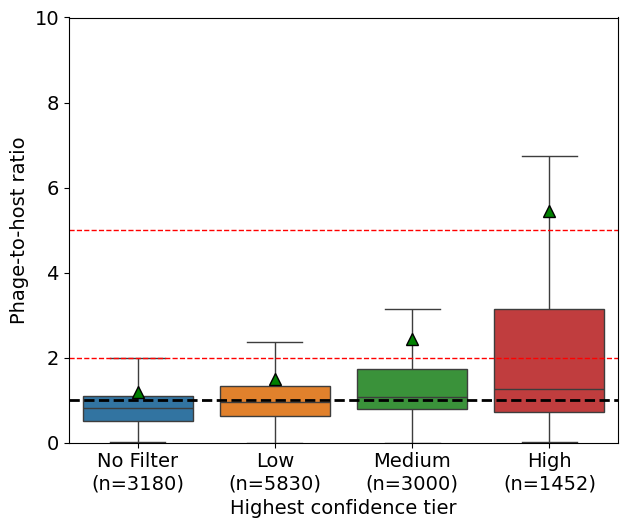

In [42]:
### Boxplot: phage-to-host ratio by highest assigned confidence tier
tier_order = ['No Filter', 'Low', 'Medium', 'High']
ratio_top_tier_df = ratio_top_tier_df[ratio_top_tier_df['top_confidence_tier'].isin(tier_order)].copy()
tier_count_map = ratio_top_tier_df['top_confidence_tier'].value_counts().to_dict()

plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(
    data=ratio_top_tier_df,
    x='top_confidence_tier',
    y='phage_host_ratio',
    order=tier_order,
    hue='top_confidence_tier',
    hue_order=tier_order,
    dodge=False,
    showfliers=False,
    showmeans=True,
    meanprops={
        'marker': '^',
        'markerfacecolor': 'green',
        'markeredgecolor': 'black',
        'markersize': 8,
    },
    legend=False,
)

ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels([f'{tier}\n(n={tier_count_map.get(tier, 0)})' for tier in tier_order])
ax.set_xlabel('Highest confidence tier')
ax.set_ylabel('Phage-to-host ratio')
# plt.yscale('log')
plt.ylim(0,10)
plt.tight_layout()
# add a black horzontal line at 1
plt.axhline(1, color='black', linestyle='--', linewidth=2)
# add red horizontal lines at 2 and 5
plt.axhline(2, color='red', linestyle='--', linewidth=1)
plt.axhline(5, color='red', linestyle='--', linewidth=1)
plt.show()


In [43]:
print("Total number of virus species that are confidently lytic:",
    cf_metag_all_data
        .select(['species_cluster_id', 'sample_id', 'phage_host_ratio', 'virus_host'])
        .join(
            species_top_tier_with_metadata.select(['species_cluster_id', 'top_confidence_tier']),
            on='species_cluster_id',
            how='left',
        )
        .join(uhvdb_species_annotations, on='species_cluster_id', how='left')
        .sort('prop_integration_related', descending=False)
        .filter(pl.col('prop_integration_related') < 0.5)
        .filter(pl.col('med_temperate_score') < 0.5)
        .filter(pl.col('count_complete') >= 1)
        .height
)
(
    cf_metag_all_data
        .select(['species_cluster_id', 'sample_id', 'phage_host_ratio', 'virus_host'])
        .join(
            species_top_tier_with_metadata.select(['species_cluster_id', 'top_confidence_tier']),
            on='species_cluster_id',
            how='left',
        )
        .join(uhvdb_species_annotations, on='species_cluster_id', how='left')
        .sort('prop_integration_related', descending=False)
        .filter(pl.col('prop_integration_related') < 0.5)
        .filter(pl.col('med_temperate_score') < 0.5)
        .filter(pl.col('count_complete') >= 1)
        .with_columns([pl.col('most_common_host_lineage').str.split(';g__').list[0].str.split('f__').list[-1].alias('host_family')])
        .group_by('host_family')
        .len()
        .sort('len', descending=True)
        .head(10)
)

Total number of virus species that are confidently lytic: 794


host_family,len
str,u32
null,333
"""Pasteurellaceae""",115
"""Neisseriaceae""",108
"""Bacteroidaceae""",102
"""Gemellaceae""",27
"""Propionibacteriaceae""",18
"""Actinomycetaceae""",14
"""Porphyromonadaceae""",12
"""Moraxellaceae""",10


In [44]:
phage_host_ratio_lst2 = []
bac_df_lst = []

for sample in sylph_tax['sample_id'].unique():
    sample_id=sample
    df = sylph_tax.filter(pl.col('sample_id') == sample_id)
    virus_df = (
        df
            .filter(pl.col('virus_host').is_not_null())
            .with_columns([
                pl.col('virus_host').str.split(';').list.join('|').alias('cf_virus_host'),
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.replace(r'.*vSPECIES-', '').str.replace(r'\|.*', '').cast(pl.Int64).alias('species_cluster_id'),
            ])
    )
    bac_df = (
        df
            .filter(pl.col('clade_name').str.starts_with('d__Bacteria'))
            .filter(
                (pl.col('clade_name').str.contains(r's__Pseudomonas aeruginosa$')) |
                (pl.col('clade_name').str.contains(r's__Staphylococcus aureus$')) |
                (pl.col('clade_name').str.contains(r's__Haemophilus influenzae$')) |
                (pl.col('clade_name').str.contains(r'g__Achromobacter')) |
                (pl.col('clade_name').str.contains(r'g__Stenotrophomonas')) |
                (pl.col('clade_name').str.contains(r'g__Burkholderia'))
            )
    )
    bac_df_lst.append(bac_df)
    # join at species level
    match = (
        virus_df
            .join(bac_df[['clade_name', 'taxonomic_abundance']], left_on='cf_virus_host', right_on='clade_name', how='inner')
            .with_columns([
                (pl.col('taxonomic_abundance') / pl.col('taxonomic_abundance_right')).alias('cf_phage_host_ratio'),
                pl.col('clade_name').str.split('t__').list[1].alias('votu_rep'),
            ])
    )
    phage_host_ratio_lst2.append(match)

phage_host_ratio_df2 = (
    pl.concat(phage_host_ratio_lst2)[['sample_id', 'species_cluster_id', 'cf_phage_host_ratio', 'cf_virus_host']]
        .join(cf_metag_all_data, on=['species_cluster_id', 'sample_id'], how='inner')
        .join(
            species_top_tier_with_metadata.select(['species_cluster_id', 'top_confidence_tier']),
            on='species_cluster_id',
            how='left',
        )
        .filter(pl.col('top_confidence_tier').is_in(['Low', 'Medium', 'High']))
)
bac_df_combined = pl.concat(bac_df_lst)

In [45]:
### Number of samples with each CF pathogen
print("Number of samples with each CF pathogen:")
(
    bac_df_combined
        .with_columns([pl.col('clade_name').str.split('|s__').list[0].str.split('g__').list[-1].alias('bac_genus')])
        .group_by('bac_genus')
        .len()
        .sort('len', descending=True)
)

Number of samples with each CF pathogen:


bac_genus,len
str,u32
"""Pseudomonas""",547
"""Staphylococcus""",515
"""Stenotrophomonas""",384
"""Burkholderia""",237
"""Achromobacter""",222
"""Haemophilus""",158


In [46]:
sample_w_phage_host = (
    phage_host_ratio_df2
        .select(['cf_phage_host_ratio', 'cf_virus_host', 'sample_id'])
        .drop_nulls(['cf_phage_host_ratio', 'cf_virus_host'])
        .with_columns([pl.col('cf_virus_host').str.split('|s__').list[0].str.split('g__').list[-1].alias('virus_host_genus')])
)
print("Number of samples with phage + host:")
sample_w_phage_host.unique(['virus_host_genus', 'sample_id']).group_by('virus_host_genus').len().sort('len', descending=True)

Number of samples with phage + host:


virus_host_genus,len
str,u32
"""Pseudomonas""",431
"""Staphylococcus""",347
"""Stenotrophomonas""",74
"""Haemophilus""",63
"""Burkholderia""",28
"""Achromobacter""",22


In [47]:
sample_w_phage_host.unique('sample_id').height

779

In [48]:
sample_w_phage_host = (
    phage_host_ratio_df2
        .select(['cf_phage_host_ratio', 'cf_virus_host', 'sample_id', 'species_cluster_id'])
        .drop_nulls(['cf_phage_host_ratio', 'cf_virus_host'])
        .with_columns([pl.col('cf_virus_host').str.split('|s__').list[0].str.split('g__').list[-1].alias('virus_host_genus')])
)
print("Number of phages per host:")
sample_w_phage_host.unique(['sample_id', 'species_cluster_id']).group_by('virus_host_genus').len().sort('len', descending=True)

Number of phages per host:


virus_host_genus,len
str,u32
"""Pseudomonas""",1448
"""Staphylococcus""",800
"""Stenotrophomonas""",203
"""Haemophilus""",116
"""Burkholderia""",78
"""Achromobacter""",27


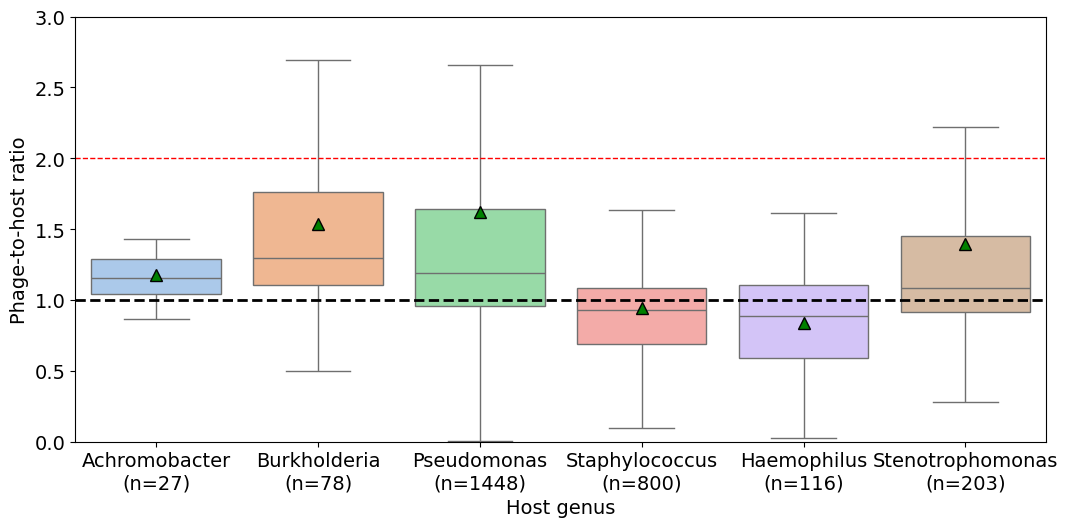

In [49]:
### Boxplot: phage-to-host ratio for CF pathogens
cf_path_phage_host = (
    phage_host_ratio_df2
        .unique(['sample_id', 'species_cluster_id'])
        .drop_nulls(['cf_phage_host_ratio', 'cf_virus_host'])
        .join(
            species_top_tier_with_metadata.select(['species_cluster_id', 'top_confidence_tier']),
            on='species_cluster_id',
            how='left',
        )
        .filter(pl.col('top_confidence_tier').is_in(['Low', 'Medium', 'High']))
        .with_columns([pl.col('cf_virus_host').str.split('|s__').list[0].str.split('g__').list[-1].alias('virus_host_genus')])
        .filter(pl.col('virus_host_genus').is_in(['Pseudomonas', 'Staphylococcus', 'Haemophilus', 'Stenotrophomonas', 'Burkholderia', 'Achromobacter']))
        .to_pandas()
)
# Stable genus order and counts for labels
genus_order = [
    'Achromobacter',
    'Burkholderia',
    'Pseudomonas',
    'Staphylococcus',
    'Haemophilus',
    'Stenotrophomonas',
    
    
]
genus_palette = sns.color_palette('pastel', n_colors=len(genus_order))
genus_count_map = cf_path_phage_host['virus_host_genus'].value_counts().to_dict()

plt.figure(figsize=(11, 5.5))
ax = sns.boxplot(
    data=cf_path_phage_host,
    x='virus_host_genus',
    y='cf_phage_host_ratio',
    order=genus_order,
    hue='virus_host_genus',
    hue_order=genus_order,
    dodge=False,
    palette=genus_palette,
    showfliers=False,
    showmeans=True,
    meanprops={
        'marker': '^',
        'markerfacecolor': 'green',
        'markeredgecolor': 'black',
        'markersize': 8,
    },
    legend=False,
)

ax.set_xticks(range(len(genus_order)))
ax.set_xticklabels([f'{genus}\n(n={genus_count_map.get(genus, 0)})' for genus in genus_order])
ax.set_xlabel('Host genus')
ax.set_ylabel('Phage-to-host ratio')
# plt.yscale('log')
plt.ylim(0,3)
plt.tight_layout()

# add a black horzontal line at 1
plt.axhline(1, color='black', linestyle='--', linewidth=2)
# add red horizontal lines at 2 and 5
plt.axhline(2, color='red', linestyle='--', linewidth=1)
plt.axhline(5, color='red', linestyle='--', linewidth=1)
plt.show()

In [50]:
cf_path_phage_host['cf_phage_host_ratio'].describe()

count    2672.000000
mean        1.359662
std         1.557278
min         0.002167
25%         0.856582
50%         1.072133
75%         1.401516
max        30.919955
Name: cf_phage_host_ratio, dtype: float64

In [51]:
### Count number of unique phage species
print("Total putatively active phage species infecting CF pathogens:",
    pl.from_pandas(cf_path_phage_host)
        .unique('species_cluster_id')
        .height
)

Total putatively active phage species infecting CF pathogens: 301


In [52]:
### Count number of phages with phage to host >= 2 and >= 5 for each CF pathogen genus
print("Number of phage species w ratio >= 2:",
    pl.from_pandas(cf_path_phage_host)
        .filter(pl.col('cf_phage_host_ratio') >= 2)
        .unique('species_cluster_id')
        .height
)

print("Number of phage species w ratio >= 2 infecting Pseudomonas:",
    pl.from_pandas(cf_path_phage_host)
        .filter(pl.col('cf_phage_host_ratio') >= 2)
        .unique('species_cluster_id')
        .filter(pl.col('virus_host_genus') == 'Pseudomonas')
        .height
)

print("Number of phage species w ratio >= 2 infecting Stenotrophomonas:",
    pl.from_pandas(cf_path_phage_host)
        .filter(pl.col('cf_phage_host_ratio') >= 2)
        .unique('species_cluster_id')
        .filter(pl.col('virus_host_genus') == 'Stenotrophomonas')
        .height
)

print("Number of Inoviridae phage species w ratio >= 2:",
    pl.from_pandas(cf_path_phage_host)
        .filter(pl.col('cf_phage_host_ratio') >= 2)
        .unique('species_cluster_id')
        .filter(pl.col('most_common_ictv_family') == 'Inoviridae')
        .height
)

Number of phage species w ratio >= 2: 131
Number of phage species w ratio >= 2 infecting Pseudomonas: 85
Number of phage species w ratio >= 2 infecting Stenotrophomonas: 16
Number of Inoviridae phage species w ratio >= 2: 41


In [53]:
41/131

0.31297709923664124

In [54]:
(
    phage_host_ratio_df2
        .with_columns([
            (pl.col('count_integration_related')/pl.col('num_genomovars_in_species')).alias('prop_integration_related'),
            (pl.col('count_integrated')/pl.col('num_genomovars_in_species')).alias('prop_integrated'),
            pl.col('cf_virus_host').str.split('|s__').list[0].str.split('g__').list[-1].alias('virus_host_genus')
        ])
        .filter(pl.col('cf_phage_host_ratio') >= 2)
        .filter(pl.col('prop_integrated') < 0.5)
        .filter(pl.col('prop_integration_related') < 0.5)
        .filter(pl.col('med_temperate_score') < 0.5)
        .unique('species_cluster_id')
        .group_by(['most_common_ictv_family', 'virus_host_genus'])
        .len()
)

most_common_ictv_family,virus_host_genus,len
str,str,u32
"""Inoviridae""","""Pseudomonas""",12
"""Unclassified""","""Pseudomonas""",1
